In [2]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# numpy  : fast array math and random number generation
# scipy  : gives us the Beta distribution and normal CDF
# matplotlib : plotting the resulting NPV distribution

In [3]:
def pert_sample(low, mode, high, n, lam=4):
    """
    Draw n random samples from a PERT distribution.

    low  : the minimum plausible value  (pessimistic)
    mode : the most likely value        (your best guess)
    high : the maximum plausible value  (optimistic)
    n    : number of random draws
    lam  : weight on the mode (default 4 is standard PERT)

    Internally this is just a Beta distribution rescaled
    to the [low, high] interval. We never need to see the
    Beta parameters directly — that's all handled below.
    """
    mean = (low + lam * mode + high) / (lam + 2)
    # This is the PERT mean formula: endpoints + weighted mode

    if mean == mode:
        alpha = 1 + lam / 2
    else:
        alpha = ((mean - low) * (2 * mode - low - high)) / \
                ((mode - mean) * (high - low))
    # alpha and beta are the two shape parameters of the
    # underlying Beta distribution. You don't need to
    # interpret them — just know larger alpha pulls the
    # distribution left, larger beta pulls it right.

    beta = alpha * (high - mean) / (mean - low)

    # Draw from Beta(alpha, beta), then rescale to [low, high]
    samples = stats.beta.rvs(alpha, beta, size=n)
    return low + samples * (high - low)

In [4]:
def correlated_uniforms(rho, n):
    """
    Generate two streams of uniform [0,1] random numbers
    that are correlated with each other at level rho.

    Why do we need this?
    If we sample amount and duration independently, we
    assume a judge's decisions on each are unrelated.
    In reality they likely move together (negatively —
    high amount, fewer years). The copula imposes that
    relationship without changing each variable's own
    distribution shape.

    How it works:
    1. Draw two correlated standard normal variables
    2. Convert each to uniform [0,1] via the normal CDF
    3. These uniforms carry the correlation through into
       whatever distribution we plug them into next.
    """
    cov_matrix = [[1, rho], [rho, 1]]
    # A 2x2 covariance matrix. Diagonal = variance of 1.
    # Off-diagonal = rho, the correlation we specified.

    normals = np.random.multivariate_normal(
        mean=[0, 0],
        cov=cov_matrix,
        size=n
    )
    # normals is shape (n, 2): n rows, 2 columns
    # column 0 = normal draws for amount
    # column 1 = normal draws for duration

    u1 = stats.norm.cdf(normals[:, 0])
    u2 = stats.norm.cdf(normals[:, 1])
    # .cdf() converts each normal value to its percentile,
    # which is always between 0 and 1 — now uniform [0,1]

    return u1, u2

In [5]:
def npv_maintenance(annual_amount, n_years, discount_rate):
    """
    Present value of receiving annual_amount per year
    for n_years, discounted at discount_rate.

    We treat each year as a separate cash flow and
    discount it back to today — same logic as npv_uneven
    from earlier, just applied to maintenance payments.

    Note: n_years comes in as a float from the PERT
    sampler, so we round it to the nearest integer first.
    """
    n_years = int(round(n_years))
    pv = 0
    for t in range(1, n_years + 1):
        pv += annual_amount / (1 + discount_rate) ** t
    return pv

In [6]:
# --- Spousal maintenance amount (annual, $) ---
amount_low  = 36_000   # worst case for payor: judge awards this minimum
amount_mode = 72_000   # your attorney's best guess
amount_high = 120_000   # worst case: judge awards this maximum

# --- Duration (years) ---
years_low  = 5         # shortest plausible award
years_mode = 10         # most likely duration
years_high = 17        # longest plausible award

# --- Correlation between amount and duration ---
rho = 0.45             # negative: higher amount → fewer years (adjust as needed)

# --- Discount rate ---
discount_rate = 0.04   # reflect cost of capital or investment return available

# --- Simulation size ---
n_sims = 1_000_000        # 50,000 simulated trial outcomes

In [7]:
# Step 6a: generate correlated uniform [0,1] pairs
u_amount, u_years = correlated_uniforms(rho, n_sims)

# Step 6b: plug those uniforms into the PERT quantile function
# ppf() = "percent point function" = inverse CDF
# It takes a probability (0-1) and returns the PERT value at that percentile
# This is how we combine the copula with our PERT distributions
mean_a = (amount_low + 4 * amount_mode + amount_high) / 6
alpha_a = ((mean_a - amount_low) * (2 * amount_mode - amount_low - amount_high)) / \
          ((amount_mode - mean_a) * (amount_high - amount_low))
beta_a  = alpha_a * (amount_high - mean_a) / (mean_a - amount_low)
amounts = amount_low + stats.beta.ppf(u_amount, alpha_a, beta_a) * (amount_high - amount_low)

mean_y = (years_low + 4 * years_mode + years_high) / 6
alpha_y = ((mean_y - years_low) * (2 * years_mode - years_low - years_high)) / \
          ((years_mode - mean_y) * (years_high - years_low))
beta_y  = alpha_y * (years_high - mean_y) / (mean_y - years_low)
years   = years_low + stats.beta.ppf(u_years, alpha_y, beta_y) * (years_high - years_low)

# Step 6c: compute NPV for each of the 50,000 simulated outcomes
npvs = np.array([
    npv_maintenance(a, y, discount_rate)
    for a, y in zip(amounts, years)
])

Mean NPV:         $     622,225
Median NPV:       $     601,375
10th percentile:  $     366,895
90th percentile:  $     908,761
Std deviation:    $     206,433


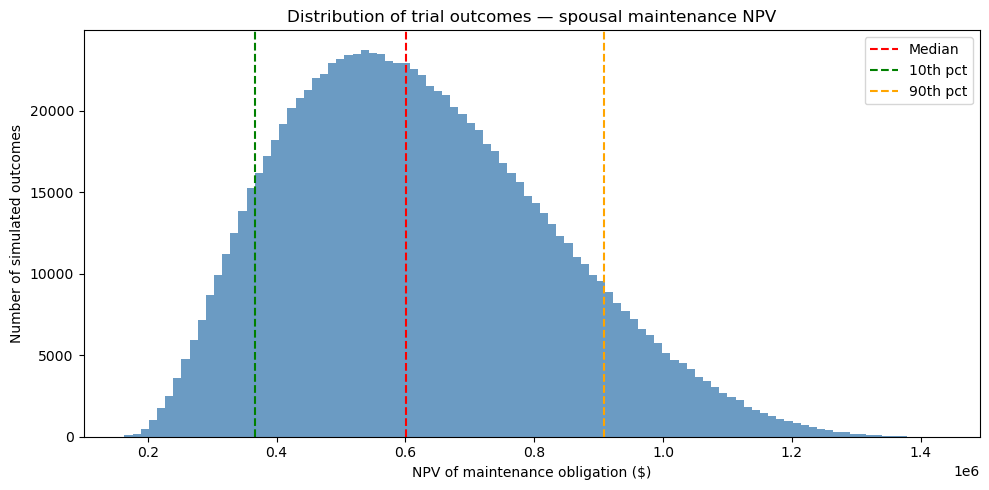

In [8]:
print(f"Mean NPV:         ${np.mean(npvs):>12,.0f}")
print(f"Median NPV:       ${np.median(npvs):>12,.0f}")
print(f"10th percentile:  ${np.percentile(npvs, 10):>12,.0f}")  # good outcome for payor
print(f"90th percentile:  ${np.percentile(npvs, 90):>12,.0f}")  # bad outcome for payor
print(f"Std deviation:    ${np.std(npvs):>12,.0f}")            # width of uncertainty

# Plot the full distribution
plt.figure(figsize=(10, 5))
plt.hist(npvs, bins=100, edgecolor='none', color='steelblue', alpha=0.8)
plt.axvline(np.median(npvs), color='red', linestyle='--', label='Median')
plt.axvline(np.percentile(npvs, 10), color='green', linestyle='--', label='10th pct')
plt.axvline(np.percentile(npvs, 90), color='orange', linestyle='--', label='90th pct')
plt.xlabel("NPV of maintenance obligation ($)")
plt.ylabel("Number of simulated outcomes")
plt.title("Distribution of trial outcomes — spousal maintenance NPV")
plt.legend()
plt.tight_layout()
plt.show()

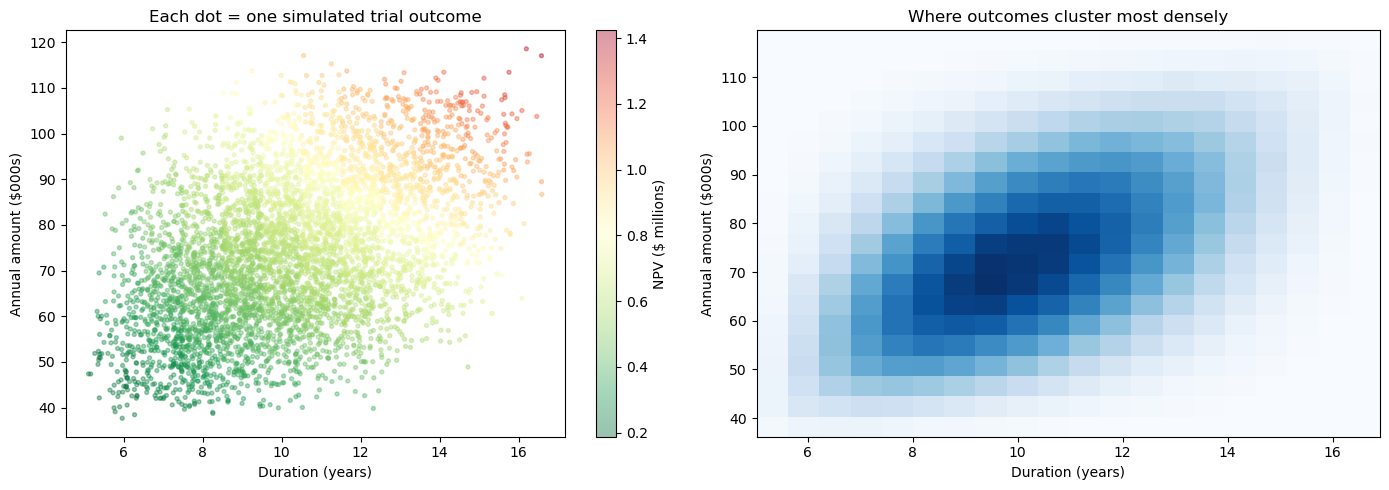

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: scatter plot of amount vs years, colored by NPV ---
# Subsample for plotting speed (5000 points is plenty visually)
idx = np.random.choice(len(amounts), 5000, replace=False)
sc = axes[0].scatter(
    years[idx],
    amounts[idx] / 1000,        # convert to thousands for readability
    c=npvs[idx] / 1_000_000,    # color = NPV in millions
    cmap='RdYlGn_r',            # red = high NPV (bad for payor), green = low
    alpha=0.4,
    s=8
)
plt.colorbar(sc, ax=axes[0], label='NPV ($ millions)')
axes[0].set_xlabel('Duration (years)')
axes[0].set_ylabel('Annual amount ($000s)')
axes[0].set_title('Each dot = one simulated trial outcome')

# --- Right: heat map of outcome frequency by amount and duration buckets ---
h, xedges, yedges = np.histogram2d(
    years,
    amounts / 1000,
    bins=20
)
axes[1].imshow(
    h.T,
    origin='lower',
    aspect='auto',
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap='Blues'
)
axes[1].set_xlabel('Duration (years)')
axes[1].set_ylabel('Annual amount ($000s)')
axes[1].set_title('Where outcomes cluster most densely')

plt.tight_layout()
plt.show()

In [10]:
def npv_even_loop(rate, cash_flow, n_periods, initial_investment):
    pv_total = 0
    for t in range(1, n_periods + 1):
        pv_total += cash_flow / (1 + rate) ** t
    return pv_total - initial_investment

In [11]:
retirement = 1_000_000
rate       = 0.04

j_monthly  = 10_000        # positive — function treats cash_flow as an outflow implicitly
j_annual   = j_monthly * 12
j_years    = 16
j_split    = 0.53          # positive — function subtracts this as initial_investment

k_monthly  = 5_833
k_annual   = k_monthly * 12
k_years    = 8
k_split    = 0.53

scen_1_jen   = npv_even_loop(rate, j_annual, j_years, 0)
scen_1_kelly = npv_even_loop(rate, k_annual, k_years, 0)

print(f"The NPV of Jen's proposal is   ${scen_1_jen:,.2f}.")
print(f"The NPV of Kelly's proposal is ${scen_1_kelly:,.2f}.")
print(f"The difference is              ${scen_1_jen - scen_1_kelly:,.2f}.")
print(f"With her proposed split of retirement and maintenance she would receive ${(retirement * j_split) + scen_1_jen:,.2f}.")
print(f"With my proposed split of retirement and maintenance she would receive ${(retirement * k_split) + scen_1_kelly:,.2f}.")

The NPV of Jen's proposal is   $1,398,275.47.
The NPV of Kelly's proposal is $471,265.21.
The difference is              $927,010.26.
With her proposed split of retirement and maintenance she would receive $1,928,275.47.
With my proposed split of retirement and maintenance she would receive $1,001,265.21.


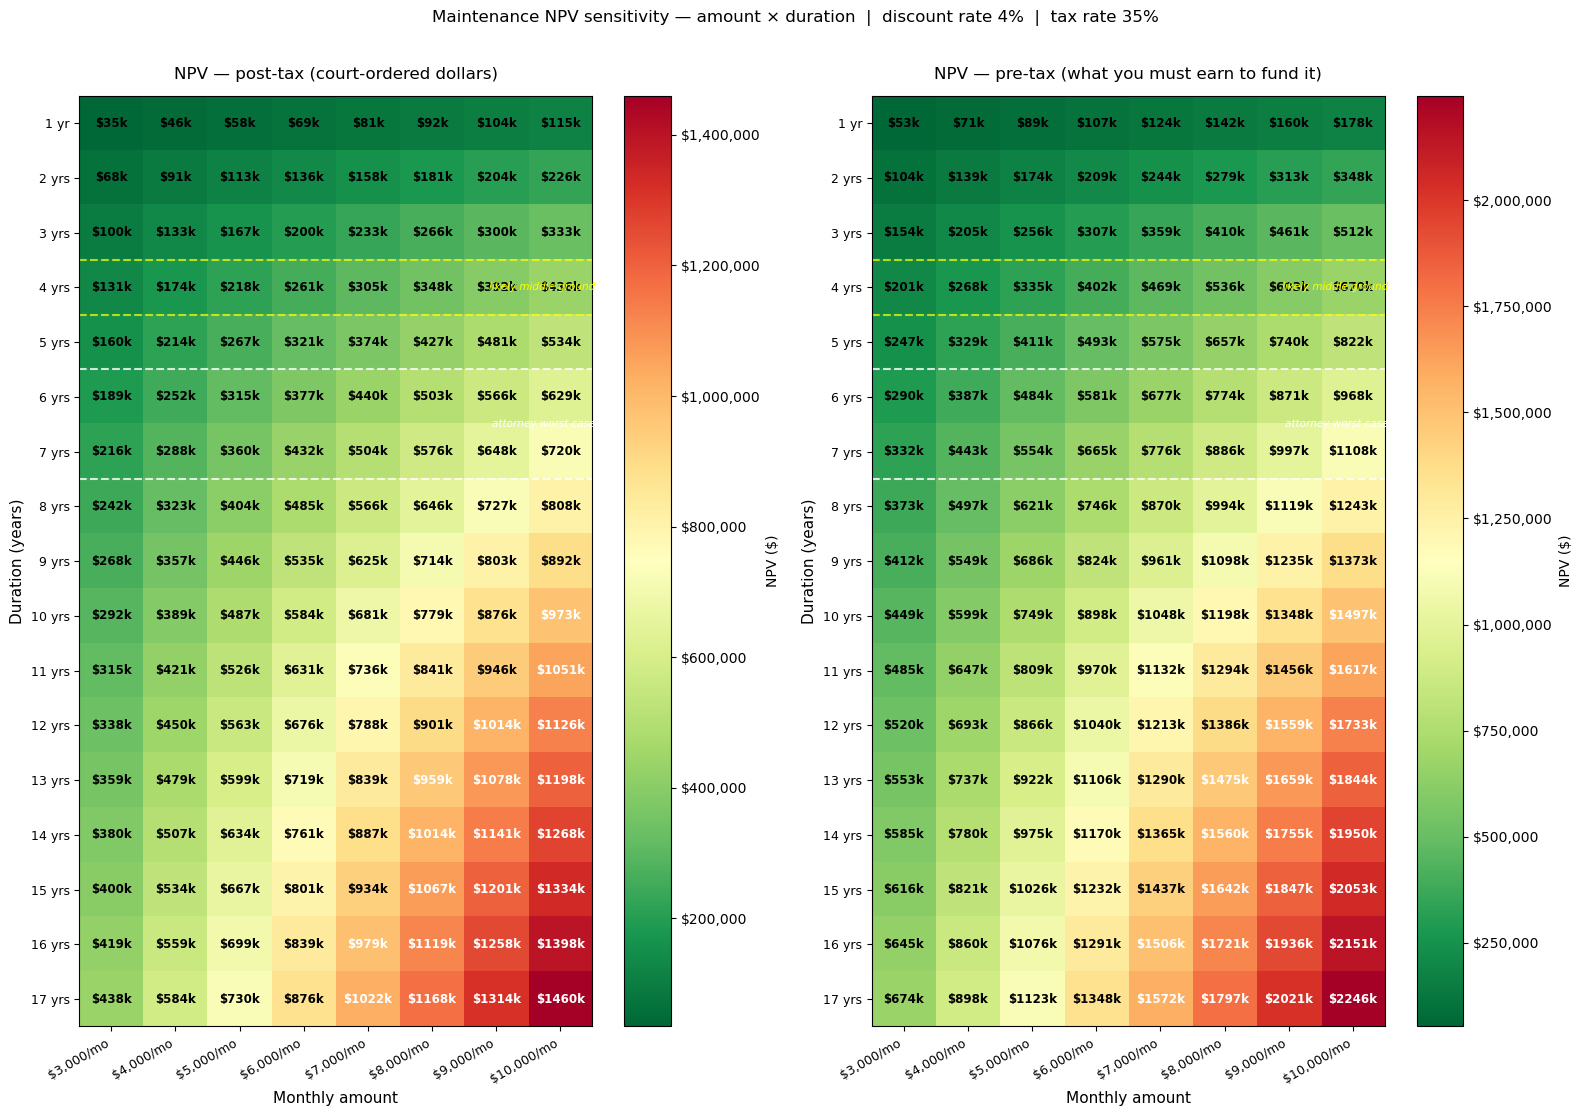

In [12]:
import matplotlib.pyplot as plt
import numpy as np

discount_rate     = 0.04
marginal_tax_rate = 0.35

# Monthly amounts on columns (fewer = wider cells)
monthly_amounts = [3_000, 4_000, 5_000, 6_000, 7_000, 8_000, 9_000, 10_000]

# Years on rows (more = taller figure, still readable)
years_range = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17]

def npv_maintenance(annual_amount, n_years, discount_rate):
    n_years = max(1, int(round(n_years)))
    pv = 0.0
    for t in range(1, n_years + 1):
        pv += annual_amount / (1 + discount_rate) ** t
    return pv

# --- Build matrices: rows = years, columns = monthly amount ---
matrix_posttax = np.zeros((len(years_range), len(monthly_amounts)))
matrix_pretax  = np.zeros((len(years_range), len(monthly_amounts)))

for i, years in enumerate(years_range):
    for j, monthly in enumerate(monthly_amounts):
        npv = npv_maintenance(monthly * 12, years, discount_rate)
        matrix_posttax[i, j] = npv
        matrix_pretax[i, j]  = npv / (1 - marginal_tax_rate)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(16, 11))  # taller figure

for ax, matrix, title in zip(
    axes,
    [matrix_posttax, matrix_pretax],
    ["NPV — post-tax (court-ordered dollars)",
     "NPV — pre-tax (what you must earn to fund it)"]
):
    im = ax.imshow(matrix, cmap="RdYlGn_r", aspect="auto")

    # Cell labels
    for i in range(len(years_range)):
        for j in range(len(monthly_amounts)):
            val = matrix[i, j]
            # White text on dark cells, black on light cells
            brightness = matrix[i, j] / matrix.max()
            text_color = "white" if brightness > 0.65 else "black"
            ax.text(j, i, f"${val/1_000:.0f}k",
                    ha="center", va="center",
                    fontsize=8.5, color=text_color, fontweight="bold")

    # Axis labels — years on y, monthly amount on x
    ax.set_yticks(range(len(years_range)))
    ax.set_yticklabels([f"{y} yr{'s' if y > 1 else ''}" for y in years_range],
                       fontsize=9)
    ax.set_xticks(range(len(monthly_amounts)))
    ax.set_xticklabels([f"${m:,}/mo" for m in monthly_amounts],
                       fontsize=9, rotation=30, ha="right")
    ax.set_ylabel("Duration (years)", fontsize=11)
    ax.set_xlabel("Monthly amount", fontsize=11)
    ax.set_title(title, fontsize=12, pad=12)

    plt.colorbar(im, ax=ax, label="NPV ($)", format="${x:,.0f}")

    # --- Highlight attorney's worst-case zone (years 6-7) ---
    ax.axhline(y=4.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    ax.axhline(y=6.5, color="white", linewidth=1.5, linestyle="--", alpha=0.8)
    ax.text(len(monthly_amounts) - 0.45, 5.5,
            "attorney worst case", color="white",
            fontsize=7.5, va="center", ha="right", style="italic")

    # --- Highlight attorney's mode (4 years) ---
    ax.axhline(y=2.5, color="yellow", linewidth=1.5, linestyle="--", alpha=0.7)
    ax.axhline(y=3.5, color="yellow", linewidth=1.5, linestyle="--", alpha=0.7)
    ax.text(len(monthly_amounts) - 0.45, 3.0,
            "likely middle ground", color="yellow",
            fontsize=7.5, va="center", ha="right", style="italic")

plt.suptitle("Maintenance NPV sensitivity — amount × duration  |  discount rate 4%  |  tax rate 35%",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

  SETTLEMENT vs TRIAL — POST-TAX DECISION ANALYSIS
  (Sunk costs excluded | July 6 forward | post-tax basis)

SUNK COSTS (already spent, not relevant to decision)
  Your fees to date:              $    50,000
  Her fees to date:               $    66,650

SETTLEMENT PATH — post-tax (certain)
────────────────────────────────────────────────────────────────
  Maintenance NPV (post-tax):     $   778,646
  Maintenance NPV (pre-tax):      $ 1,197,917  ← true economic cost
  Asset division to spouse:       $   530,000
  Your mediation fees:            $    10,000
  Her mediation fees:             her problem
────────────────────────────────────────────────────────────────
  TOTAL SETTLEMENT (post-tax):    $ 1,318,646
  TOTAL SETTLEMENT (pre-tax):     $ 1,737,917  ← true economic cost

TRIAL PATH — post-tax (uncertain)
────────────────────────────────────────────────────────────────
  10th percentile (good day):     $   969,880
  25th percentile:                $ 1,076,094
  Median (50th):   

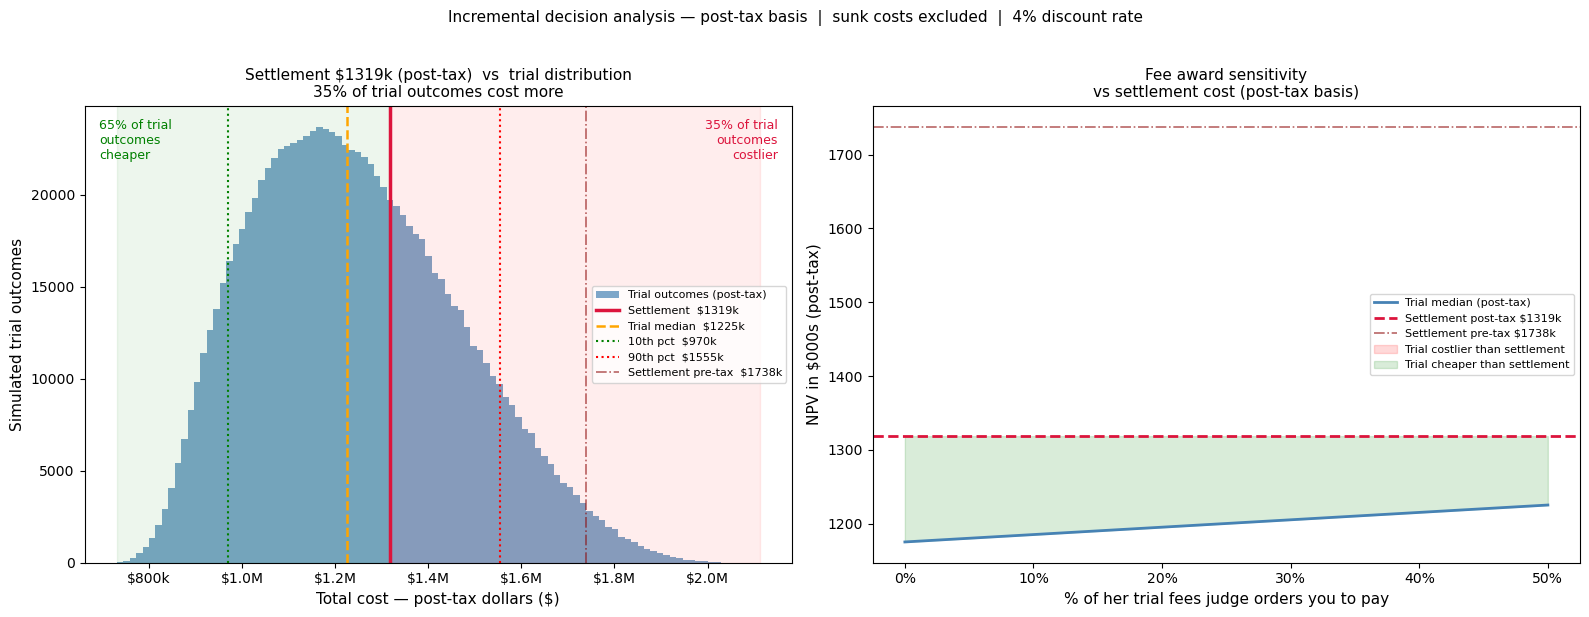

In [13]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

# ---------------------------------------------------------------
# INPUTS
# ---------------------------------------------------------------

# --- Her settlement offer ---
offer_monthly   =   8_000
offer_years     =      10
offer_asset_pct =    0.53

# --- Sunk costs (excluded from decision) ---
kelly_fees_sunk =  50_000
jen_fees_sunk   =  66_650

# --- Incremental legal fees from July 6 forward ---
kelly_mediation_fees =  10_000
kelly_trial_fees     =  75_000
jen_mediation_fees   =  15_000    # her problem at settlement
jen_trial_fees       = 100_000    # subject to fee award at trial

# --- Her fee award: PERT on percentage she could recover ---
pct_her_fees_low  = 0.00
pct_her_fees_mode = 0.50
pct_her_fees_high = 1.00

# --- Retirement portfolio ---
portfolio_value  = 1_000_000
trial_asset_pct  =      0.50    # Washington default at trial

# --- Model parameters ---
discount_rate     = 0.04
marginal_tax_rate = 0.35        # kept for pre-tax display only
amount_low        = 48_000
amount_mode       = 96_000
amount_high       = 120_000
years_low         = 3.0
years_mode        = 7.0
years_high        = 17.0
rho               = 0.45
n_sims            = 1_000_000

# ---------------------------------------------------------------
# HELPER FUNCTIONS
# ---------------------------------------------------------------

def npv_posttax(annual_amount, n_years, discount_rate):
    """
    NPV in post-tax dollars — the legal obligation as the
    court specifies it. This is the correct basis for
    comparing settlement offers to trial outcomes.
    """
    n_years = max(1, int(round(n_years)))
    pv = 0.0
    for t in range(1, n_years + 1):
        pv += annual_amount / (1 + discount_rate) ** t
    return pv

def npv_pretax(annual_amount, n_years, discount_rate,
               tax_rate):
    """
    NPV grossed up to pre-tax dollars — the true economic
    cost to you. Displayed alongside for context but NOT
    used as the basis for settlement comparison.
    """
    return npv_posttax(
        annual_amount / (1 - tax_rate),
        n_years,
        discount_rate
    )

def pert_params(lo, mode, hi, lam=4):
    mean = (lo + lam * mode + hi) / (lam + 2)
    if abs(mean - mode) < 1e-9:
        alpha = 1 + lam / 2
    else:
        alpha = ((mean - lo) * (2 * mode - lo - hi)) / \
                ((mode - mean) * (hi - lo))
    beta = alpha * (hi - mean) / (mean - lo)
    return alpha, beta

def pert_sample_from_uniform(u, lo, mode, hi, lam=4):
    alpha, beta = pert_params(lo, mode, hi, lam)
    return lo + stats.beta.ppf(
        np.clip(u, 1e-6, 1 - 1e-6), alpha, beta
    ) * (hi - lo)

# ---------------------------------------------------------------
# STEP 1 — Settlement cost in post-tax dollars
# ---------------------------------------------------------------

settlement_maint_posttax = npv_posttax(
    offer_monthly * 12, offer_years, discount_rate
)
settlement_maint_pretax  = npv_pretax(
    offer_monthly * 12, offer_years,
    discount_rate, marginal_tax_rate
)
settlement_asset_cost    = portfolio_value * offer_asset_pct
settlement_total_posttax = (settlement_maint_posttax
                             + settlement_asset_cost
                             + kelly_mediation_fees)
settlement_total_pretax  = (settlement_maint_pretax
                             + settlement_asset_cost
                             + kelly_mediation_fees)

# ---------------------------------------------------------------
# STEP 2 — Monte Carlo for trial path in post-tax dollars
# ---------------------------------------------------------------

cov     = [[1, rho], [rho, 1]]
normals = np.random.multivariate_normal([0, 0], cov, size=n_sims)
u_amt   = stats.norm.cdf(normals[:, 0])
u_yrs   = stats.norm.cdf(normals[:, 1])

amounts = pert_sample_from_uniform(
    u_amt, amount_low, amount_mode, amount_high
)
years   = pert_sample_from_uniform(
    u_yrs, years_low, years_mode, years_high
)

# Post-tax NPV for each simulation — the apples-to-apples basis
trial_maint_posttax = np.array([
    npv_posttax(a, y, discount_rate)
    for a, y in zip(amounts, years)
])

# Pre-tax equivalent for context display
trial_maint_pretax = np.array([
    npv_pretax(a, y, discount_rate, marginal_tax_rate)
    for a, y in zip(amounts, years)
])

# ---------------------------------------------------------------
# STEP 3 — Her fee award: PERT-sampled
# ---------------------------------------------------------------

u_fees = np.random.uniform(0, 1, size=n_sims)
pct_her_fees_draws = pert_sample_from_uniform(
    u_fees,
    pct_her_fees_low,
    pct_her_fees_mode + 1e-9,
    pct_her_fees_high
)
her_fees_awarded = pct_her_fees_draws * jen_trial_fees

# ---------------------------------------------------------------
# STEP 4 — Total trial cost per simulation (post-tax basis)
# ---------------------------------------------------------------

trial_total_posttax = (
    trial_maint_posttax
    + portfolio_value * trial_asset_pct
    + kelly_trial_fees
    + her_fees_awarded
)

# Pre-tax equivalent of full trial cost for context
trial_total_pretax = (
    trial_maint_pretax
    + portfolio_value * trial_asset_pct
    + kelly_trial_fees
    + her_fees_awarded
)

# ---------------------------------------------------------------
# STEP 5 — Decision statistics (post-tax basis)
# ---------------------------------------------------------------

p10 = np.percentile(trial_total_posttax, 10)
p25 = np.percentile(trial_total_posttax, 25)
p50 = np.percentile(trial_total_posttax, 50)
p75 = np.percentile(trial_total_posttax, 75)
p90 = np.percentile(trial_total_posttax, 90)

pct_trial_worse  = np.mean(
    trial_total_posttax > settlement_total_posttax
) * 100
pct_trial_better = 100 - pct_trial_worse
expected_trial   = np.mean(trial_total_posttax)
avg_fees_awarded = np.mean(her_fees_awarded)

# ---------------------------------------------------------------
# STEP 6 — Print decision summary
# ---------------------------------------------------------------

sep  = "=" * 64
sep2 = "─" * 64

print(sep)
print("  SETTLEMENT vs TRIAL — POST-TAX DECISION ANALYSIS")
print("  (Sunk costs excluded | July 6 forward | post-tax basis)")
print(sep)

print(f"\nSUNK COSTS (already spent, not relevant to decision)")
print(f"  Your fees to date:              ${kelly_fees_sunk:>10,.0f}")
print(f"  Her fees to date:               ${jen_fees_sunk:>10,.0f}")

print(f"\nSETTLEMENT PATH — post-tax (certain)")
print(sep2)
print(f"  Maintenance NPV (post-tax):     ${settlement_maint_posttax:>10,.0f}")
print(f"  Maintenance NPV (pre-tax):      ${settlement_maint_pretax:>10,.0f}  ← true economic cost")
print(f"  Asset division to spouse:       ${settlement_asset_cost:>10,.0f}")
print(f"  Your mediation fees:            ${kelly_mediation_fees:>10,.0f}")
print(f"  Her mediation fees:             {'her problem':>10}")
print(sep2)
print(f"  TOTAL SETTLEMENT (post-tax):    ${settlement_total_posttax:>10,.0f}")
print(f"  TOTAL SETTLEMENT (pre-tax):     ${settlement_total_pretax:>10,.0f}  ← true economic cost")

print(f"\nTRIAL PATH — post-tax (uncertain)")
print(sep2)
print(f"  10th percentile (good day):     ${p10:>10,.0f}")
print(f"  25th percentile:                ${p25:>10,.0f}")
print(f"  Median (50th):                  ${p50:>10,.0f}")
print(f"  75th percentile:                ${p75:>10,.0f}")
print(f"  90th percentile (bad day):      ${p90:>10,.0f}")
print(f"  Expected value of trial:        ${expected_trial:>10,.0f}")
print(f"  Avg her fees awarded:           ${avg_fees_awarded:>10,.0f}")

print(f"\nTHE DECISION")
print(sep2)
vs_med    = settlement_total_posttax - p50
direction = ("BELOW median — favorable"
             if vs_med < 0 else "ABOVE median — negotiate")
print(f"  Settlement vs trial median:     {direction}")
print(f"  Difference from median:         ${abs(vs_med):>10,.0f}")
print(f"  Trial outcomes > settlement:    {pct_trial_worse:>9.1f}%")
print(f"  Trial outcomes < settlement:    {pct_trial_better:>9.1f}%")
print(f"\n  NOTE: pre-tax cost is {marginal_tax_rate*100:.0f}% higher than post-tax.")
print(f"  The court sees post-tax. You feel pre-tax.")
print(f"  Both numbers matter — for different audiences.")

# ---------------------------------------------------------------
# STEP 7 — Plot
# ---------------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: main decision histogram (post-tax) ---
ax1.hist(trial_total_posttax, bins=100, color="steelblue",
         alpha=0.7, edgecolor="none",
         label="Trial outcomes (post-tax)")

ax1.axvline(settlement_total_posttax, color="crimson",
            linewidth=2.5, linestyle="-",
            label=f"Settlement  ${settlement_total_posttax/1000:.0f}k")
ax1.axvline(p50, color="orange", linewidth=1.8, linestyle="--",
            label=f"Trial median  ${p50/1000:.0f}k")
ax1.axvline(p10, color="green",  linewidth=1.5, linestyle=":",
            label=f"10th pct  ${p10/1000:.0f}k")
ax1.axvline(p90, color="red",    linewidth=1.5, linestyle=":",
            label=f"90th pct  ${p90/1000:.0f}k")

# Second vertical line showing pre-tax settlement for context
ax1.axvline(settlement_total_pretax, color="darkred",
            linewidth=1.2, linestyle="-.", alpha=0.6,
            label=f"Settlement pre-tax  ${settlement_total_pretax/1000:.0f}k")

ax1.axvspan(trial_total_posttax.min(), settlement_total_posttax,
            alpha=0.07, color="green")
ax1.axvspan(settlement_total_posttax, trial_total_posttax.max(),
            alpha=0.07, color="red")

ax1.text(0.02, 0.97,
         f"{pct_trial_better:.0f}% of trial\noutcomes\ncheaper",
         transform=ax1.transAxes, fontsize=9,
         va="top", color="green")
ax1.text(0.98, 0.97,
         f"{pct_trial_worse:.0f}% of trial\noutcomes\ncostlier",
         transform=ax1.transAxes, fontsize=9,
         va="top", ha="right", color="crimson")

ax1.set_xlabel("Total cost — post-tax dollars ($)", fontsize=11)
ax1.set_ylabel("Simulated trial outcomes", fontsize=11)
ax1.set_title(
    f"Settlement ${settlement_total_posttax/1000:.0f}k (post-tax)  vs  "
    f"trial distribution\n"
    f"{pct_trial_worse:.0f}% of trial outcomes cost more",
    fontsize=11
)
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda x, _: f"${x/1_000_000:.1f}M"
        if x >= 1_000_000 else f"${x/1_000:.0f}k"
    )
)

# --- Right: fee award sensitivity (post-tax) ---
fee_pcts = np.linspace(0, 0.50, 100)
trial_medians_by_fee = [
    np.median(
        trial_maint_posttax
        + portfolio_value * trial_asset_pct
        + kelly_trial_fees
        + fp * jen_trial_fees
    )
    for fp in fee_pcts
]

ax2.plot(fee_pcts * 100,
         [t / 1000 for t in trial_medians_by_fee],
         color="steelblue", linewidth=2,
         label="Trial median (post-tax)")
ax2.axhline(settlement_total_posttax / 1000,
            color="crimson", linewidth=2, linestyle="--",
            label=f"Settlement post-tax ${settlement_total_posttax/1000:.0f}k")
ax2.axhline(settlement_total_pretax / 1000,
            color="darkred", linewidth=1.2,
            linestyle="-.", alpha=0.6,
            label=f"Settlement pre-tax ${settlement_total_pretax/1000:.0f}k")

ax2.fill_between(
    fee_pcts * 100,
    [t / 1000 for t in trial_medians_by_fee],
    settlement_total_posttax / 1000,
    where=[t > settlement_total_posttax
           for t in trial_medians_by_fee],
    alpha=0.15, color="red",
    label="Trial costlier than settlement"
)
ax2.fill_between(
    fee_pcts * 100,
    [t / 1000 for t in trial_medians_by_fee],
    settlement_total_posttax / 1000,
    where=[t <= settlement_total_posttax
           for t in trial_medians_by_fee],
    alpha=0.15, color="green",
    label="Trial cheaper than settlement"
)

ax2.set_xlabel("% of her trial fees judge orders you to pay",
               fontsize=11)
ax2.set_ylabel("NPV in $000s (post-tax)", fontsize=11)
ax2.set_title(
    "Fee award sensitivity\nvs settlement cost (post-tax basis)",
    fontsize=11
)
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.0f}%")
)
ax2.legend(fontsize=8)

plt.suptitle(
    "Incremental decision analysis — post-tax basis  |  "
    "sunk costs excluded  |  4% discount rate",
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

In [14]:
# Quick calculator to run during caucus breaks
# Plug in her latest offer each time she moves

def quick_compare(offer_monthly, offer_years, offer_asset_pct,
                  portfolio_value, kelly_mediation_fees,
                  trial_median, discount_rate=0.04):
    """
    Instant settlement vs trial comparison.
    Run this every time her offer changes during mediation.
    """
    # Settlement cost
    annual = offer_monthly * 12
    n      = max(1, int(round(offer_years)))
    maint_npv = sum(annual / (1 + discount_rate)**t
                    for t in range(1, n + 1))
    asset_cost      = portfolio_value * offer_asset_pct
    settlement_total = maint_npv + asset_cost + kelly_mediation_fees

    # Comparison
    vs_median   = settlement_total - trial_median
    direction   = "FAVORABLE" if vs_median < 0 else "NEGOTIATE"

    print(f"\n--- Offer: ${offer_monthly:,}/mo × {offer_years} yrs "
          f"| {offer_asset_pct*100:.0f}% portfolio ---")
    print(f"  Maintenance NPV:      ${maint_npv:>10,.0f}")
    print(f"  Asset cost:           ${asset_cost:>10,.0f}")
    print(f"  Total settlement:     ${settlement_total:>10,.0f}")
    print(f"  Trial median:         ${trial_median:>10,.0f}")
    print(f"  Difference:           ${abs(vs_median):>10,.0f} "
          f"{'below' if vs_median < 0 else 'above'} median")
    print(f"  Verdict:              {direction}")

    return settlement_total

# Example: run this each time she moves her position
trial_median = 650_000   # from your pre-mediation Monte Carlo run

# Her opening
quick_compare(10_000, 15, 0.53, 1_000_000, 10_000, trial_median)

# After first concession
quick_compare(9_000, 12, 0.53, 1_000_000, 10_000, trial_median)

# Approaching agreement
quick_compare(8_000, 7, 0.50, 1_000_000, 10_000, trial_median)


--- Offer: $10,000/mo × 15 yrs | 53% portfolio ---
  Maintenance NPV:      $ 1,334,206
  Asset cost:           $   530,000
  Total settlement:     $ 1,874,206
  Trial median:         $   650,000
  Difference:           $ 1,224,206 above median
  Verdict:              NEGOTIATE

--- Offer: $9,000/mo × 12 yrs | 53% portfolio ---
  Maintenance NPV:      $ 1,013,588
  Asset cost:           $   530,000
  Total settlement:     $ 1,553,588
  Trial median:         $   650,000
  Difference:           $   903,588 above median
  Verdict:              NEGOTIATE

--- Offer: $8,000/mo × 7 yrs | 50% portfolio ---
  Maintenance NPV:      $   576,197
  Asset cost:           $   500,000
  Total settlement:     $ 1,086,197
  Trial median:         $   650,000
  Difference:           $   436,197 above median
  Verdict:              NEGOTIATE


1086197.2483150477


  HER LIKELY OPENING OFFER
  PV1 — Maintenance NPV:         $ 1,126,209
         (10,000/mo × 12 yrs)
  PV2 — Child support ext NPV:   $    39,708
         (36 months extension)
  PV3 — Asset division:          $   550,000
         (55.0% of $1,000,000)
  Your mediation fees:           $    10,000
  ────────────────────────────────────────────
  TOTAL OFFER:                   $ 1,725,916

  Trial reference points:
    10th pct (good day):         $   799,127
    25th pct:                    $   869,314
    Median (indifference):       $   953,442
    75th pct:                    $ 1,041,997
    90th pct (bad day):          $ 1,120,056

  Trial outcomes costlier:             0.0%

  VERDICT: STRONG REJECT — trial almost certainly cheaper

  This offer exceeds the 90th percentile of trial outcomes.
  Under our assumptions, only 0% of trial outcomes
  cost more. This offer is not grounded in Washington case
  law as our model applies it. Do not accept.

  MIDDLE-GROUND SCENARIO
  PV1 — M

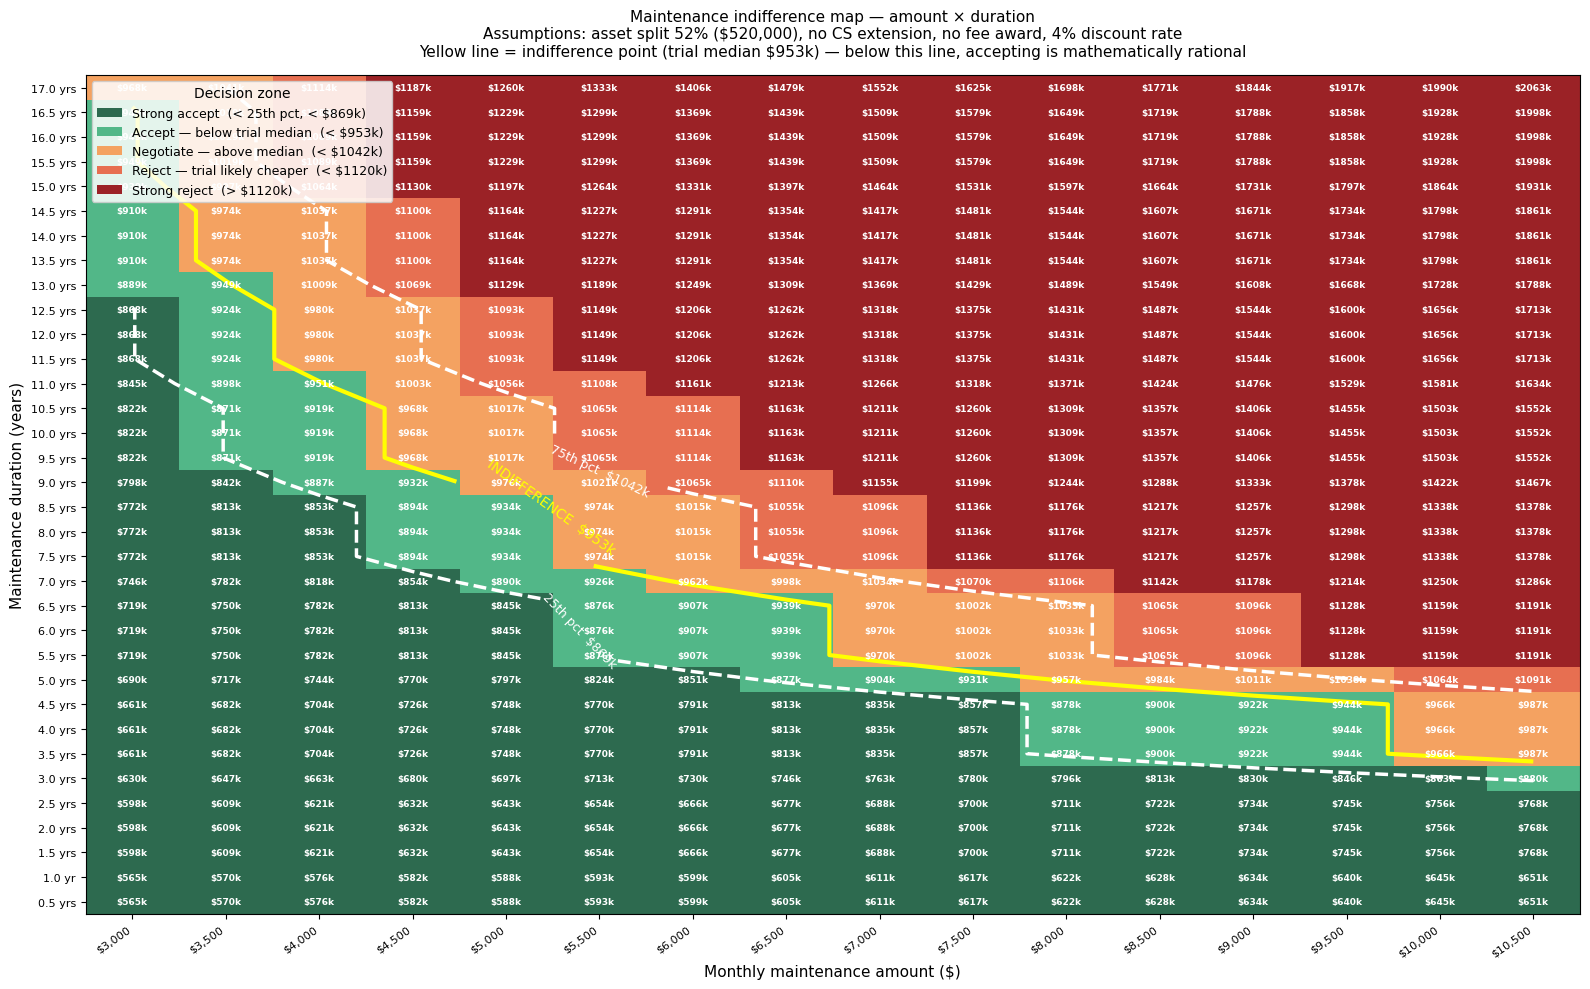

In [15]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm

# ---------------------------------------------------------------
# SECTION 1 — MODEL PARAMETERS (attorney-calibrated)
# ---------------------------------------------------------------

discount_rate     = 0.04
marginal_tax_rate = 0.35
portfolio_value   = 1_000_000

# Maintenance PERT inputs
amount_low   =  48_000
amount_mode  =  96_000
amount_high  = 120_000
years_low    =     0.5
years_mode   =     4.0
years_high   =     7.0
rho          =     0.30

# Child support extension PERT inputs
# Judge can extend 0-3 years beyond twins' 18th birthday
# given special needs; mode at 1 year reflecting partial
# acknowledgment of needs without full extension
cs_monthly       =  1_192.38   # current child support order
cs_ext_low       =       0.0   # judge declines extension
cs_ext_mode      =       1.0   # most likely: 1 year extension
cs_ext_high      =       3.0   # maximum: 3 years

# Asset division PERT inputs
# Washington default is 50/50; she may argue for more
asset_pct_low    =  0.50       # 50/50 Washington default
asset_pct_mode   =  0.52       # slight deviation toward her
asset_pct_high   =  0.57       # aggressive deviation

# Legal fees
kelly_mediation_fees =  10_000
kelly_trial_fees     =  75_000
jen_trial_fees       = 100_000

# Her fee award: PERT on percentage
pct_her_fees_low  = 0.000
pct_her_fees_mode = 0.100      # nudged off zero
pct_her_fees_high = 0.250

n_sims = 50_000

# ---------------------------------------------------------------
# SECTION 2 — HELPER FUNCTIONS
# ---------------------------------------------------------------

def npv_stream(monthly_amount, n_years, rate):
    """
    Post-tax NPV of a monthly payment stream.
    Converts monthly to annual then discounts year by year.
    This is the court-ordered dollar basis.
    """
    annual  = monthly_amount * 12
    n_years = max(1, int(round(n_years)))
    return sum(annual / (1 + rate)**t for t in range(1, n_years + 1))

def npv_pretax_gross(monthly_amount, n_years, rate, tax_rate):
    """Pre-tax equivalent for economic cost display."""
    return npv_stream(monthly_amount / (1 - tax_rate), n_years, rate)

def pert_params(lo, mode, hi, lam=4):
    mean = (lo + lam * mode + hi) / (lam + 2)
    if abs(mean - mode) < 1e-9:
        alpha = 1 + lam / 2
    else:
        alpha = ((mean - lo) * (2 * mode - lo - hi)) / \
                ((mode - mean) * (hi - lo))
    beta = alpha * (hi - mean) / (mean - lo)
    return alpha, beta

def pert_draw(u, lo, mode, hi, lam=4):
    alpha, beta = pert_params(lo, mode, hi, lam)
    return lo + stats.beta.ppf(
        np.clip(u, 1e-6, 1 - 1e-6), alpha, beta
    ) * (hi - lo)

# ---------------------------------------------------------------
# SECTION 3 — MONTE CARLO: TRIAL DISTRIBUTION
# Each simulation draws:
#   (1) maintenance amount and duration (correlated via copula)
#   (2) child support extension duration
#   (3) asset division percentage
#   (4) her fee award percentage
# ---------------------------------------------------------------

cov     = [[1, rho], [rho, 1]]
normals = np.random.multivariate_normal([0, 0], cov, size=n_sims)
u_amt   = stats.norm.cdf(normals[:, 0])
u_yrs   = stats.norm.cdf(normals[:, 1])

# Independent draws for the other uncertain variables
u_cs    = np.random.uniform(0, 1, n_sims)
u_asset = np.random.uniform(0, 1, n_sims)
u_fees  = np.random.uniform(0, 1, n_sims)

# Sample each variable
sim_amounts   = pert_draw(u_amt,   amount_low,       amount_mode,       amount_high)
sim_years     = pert_draw(u_yrs,   years_low,        years_mode,        years_high)
sim_cs_ext    = pert_draw(u_cs,    cs_ext_low,       cs_ext_mode,       cs_ext_high)
sim_asset_pct = pert_draw(u_asset, asset_pct_low,    asset_pct_mode,    asset_pct_high)
sim_fee_pct   = pert_draw(u_fees,  pct_her_fees_low, pct_her_fees_mode, pct_her_fees_high)

# NPV of each component across all simulations
pv1_trial = np.array([                          # maintenance
    npv_stream(a / 12, y, discount_rate)
    for a, y in zip(sim_amounts, sim_years)
])

pv2_trial = np.array([                          # child support extension
    npv_stream(cs_monthly, ext, discount_rate)
    for ext in sim_cs_ext
])

pv3_trial = sim_asset_pct * portfolio_value     # asset division

pv4_trial = kelly_trial_fees                    # your legal fees (certain)

pv5_trial = sim_fee_pct * jen_trial_fees        # her fees awarded

trial_total = (pv1_trial + pv2_trial + pv3_trial
               + pv4_trial + pv5_trial)

# ---------------------------------------------------------------
# SECTION 4 — INDIFFERENCE THRESHOLDS
# ---------------------------------------------------------------

# Key percentiles of the trial distribution
p10 = np.percentile(trial_total, 10)
p25 = np.percentile(trial_total, 25)
p50 = np.percentile(trial_total, 50)    # indifference point
p75 = np.percentile(trial_total, 75)
p90 = np.percentile(trial_total, 90)

# Component breakdowns at the median (for anchoring)
pv1_median    = np.median(pv1_trial)
pv2_median    = np.median(pv2_trial)
pv3_median    = np.median(pv3_trial)
avg_fees      = np.mean(pv5_trial)

# Indifference thresholds for settlement evaluation
# Defined as the settlement total that equals each trial percentile
# Below p50 = probably accept | above p75 = probably reject
indiff_accept     = p50     # rational acceptance threshold
indiff_consider   = p75     # above here, negotiate harder
indiff_reject     = p90     # above here, trial is likely better

# ---------------------------------------------------------------
# SECTION 5 — SETTLEMENT OFFER EVALUATOR
# ---------------------------------------------------------------

def evaluate_offer(offer_monthly, offer_years,
                   offer_asset_pct, offer_cs_months=0,
                   label="Offer"):
    """
    Evaluate a specific settlement offer against the trial
    distribution. Returns total and prints a clear verdict.

    offer_monthly   : proposed monthly maintenance ($)
    offer_years     : proposed maintenance duration (years)
    offer_asset_pct : proposed share of portfolio to spouse
    offer_cs_months : proposed child support extension (months)
    """
    # PV1: maintenance
    pv1 = npv_stream(offer_monthly, offer_years, discount_rate)

    # PV2: child support extension
    pv2 = npv_stream(cs_monthly, offer_cs_months / 12, discount_rate)

    # PV3: assets
    pv3 = offer_asset_pct * portfolio_value

    # Settlement total (mediation fees certain)
    total = pv1 + pv2 + pv3 + kelly_mediation_fees

    pct_worse = np.mean(trial_total > total) * 100

    # Verdict with explicit assumption language
    if total < p25:
        verdict = "STRONG ACCEPT"
        color   = "darkgreen"
        explanation = (
            f"This offer is below the 25th percentile of trial outcomes.\n"
            f"  Under the assumptions that a judge draws from our PERT\n"
            f"  distributions — maintenance between ${amount_low/12:,.0f}/mo\n"
            f"  and ${amount_high/12:,.0f}/mo, duration {years_low:.1f}–{years_high:.1f} yrs,\n"
            f"  child support extension 0–{cs_ext_high:.0f} yrs, asset split\n"
            f"  {asset_pct_low*100:.0f}–{asset_pct_high*100:.0f}% — 75% of trial outcomes\n"
            f"  cost MORE than this settlement. Accept."
        )
    elif total < p50:
        verdict = "ACCEPT (below trial median)"
        color   = "green"
        explanation = (
            f"This offer is below the trial median.\n"
            f"  Under our assumptions, more than half of trial outcomes\n"
            f"  cost more than this settlement ({pct_worse:.0f}% do).\n"
            f"  You dislike this offer but the math favors acceptance.\n"
            f"  Accepting is rational even if it feels uncomfortable."
        )
    elif total < p75:
        verdict = "NEGOTIATE — above median but within range"
        color   = "orange"
        explanation = (
            f"This offer is above the trial median but below the 75th\n"
            f"  percentile. Under our assumptions, {pct_worse:.0f}% of trial\n"
            f"  outcomes cost more. Push back on amount or duration\n"
            f"  to get below the median before accepting."
        )
    elif total < p90:
        verdict = "REJECT — trial likely cheaper"
        color   = "red"
        explanation = (
            f"This offer exceeds the 75th percentile of trial outcomes.\n"
            f"  Under our assumptions, only {pct_worse:.0f}% of trial outcomes\n"
            f"  cost more. The math favors trial unless you place very\n"
            f"  high value on certainty or fear a specific bad-judge scenario."
        )
    else:
        verdict = "STRONG REJECT — trial almost certainly cheaper"
        color   = "darkred"
        explanation = (
            f"This offer exceeds the 90th percentile of trial outcomes.\n"
            f"  Under our assumptions, only {pct_worse:.0f}% of trial outcomes\n"
            f"  cost more. This offer is not grounded in Washington case\n"
            f"  law as our model applies it. Do not accept."
        )

    print(f"\n{'='*62}")
    print(f"  {label.upper()}")
    print(f"{'='*62}")
    print(f"  PV1 — Maintenance NPV:         ${pv1:>10,.0f}")
    print(f"         ({offer_monthly:,}/mo × {offer_years} yrs)")
    print(f"  PV2 — Child support ext NPV:   ${pv2:>10,.0f}")
    print(f"         ({offer_cs_months} months extension)")
    print(f"  PV3 — Asset division:          ${pv3:>10,.0f}")
    print(f"         ({offer_asset_pct*100:.1f}% of ${portfolio_value:,})")
    print(f"  Your mediation fees:           ${kelly_mediation_fees:>10,.0f}")
    print(f"  {'─'*44}")
    print(f"  TOTAL OFFER:                   ${total:>10,.0f}")
    print(f"\n  Trial reference points:")
    print(f"    10th pct (good day):         ${p10:>10,.0f}")
    print(f"    25th pct:                    ${p25:>10,.0f}")
    print(f"    Median (indifference):       ${p50:>10,.0f}")
    print(f"    75th pct:                    ${p75:>10,.0f}")
    print(f"    90th pct (bad day):          ${p90:>10,.0f}")
    print(f"\n  Trial outcomes costlier:       {pct_worse:>9.1f}%")
    print(f"\n  VERDICT: {verdict}")
    print(f"\n  {explanation}")

    return total, pct_worse

# ---------------------------------------------------------------
# SECTION 6 — RUN OFFER EVALUATIONS
# Plug in her actual offers as they emerge on July 6
# ---------------------------------------------------------------

# Her likely opening position (aggressive)
evaluate_offer(
    offer_monthly   = 10_000,
    offer_years     = 12,
    offer_asset_pct = 0.55,
    offer_cs_months = 36,
    label="Her likely opening offer"
)

# A middle-ground scenario
evaluate_offer(
    offer_monthly   = 8_000,
    offer_years     = 7,
    offer_asset_pct = 0.53,
    offer_cs_months = 18,
    label="Middle-ground scenario"
)

# Near your walk-in target
evaluate_offer(
    offer_monthly   = 6_000,
    offer_years     = 4,
    offer_asset_pct = 0.50,
    offer_cs_months = 12,
    label="Near your walk-in target"
)

# ---------------------------------------------------------------
# SECTION 7 — INDIFFERENCE CURVE HEATMAP
# Shows every combination of monthly amount and duration
# with color zones keyed to the trial percentile thresholds
# ---------------------------------------------------------------

monthly_range = np.arange(3_000, 11_000, 500)
years_range   = np.arange(0.5,   17.5,   0.5)

# Fixed assumptions for the heatmap:
# asset split at mode, no CS extension, no fee award
# so the heatmap isolates the maintenance decision
heatmap_asset = asset_pct_mode * portfolio_value
heatmap_other = kelly_mediation_fees + heatmap_asset

Z = np.zeros((len(years_range), len(monthly_range)))
for i, yrs in enumerate(years_range):
    for j, mo in enumerate(monthly_range):
        Z[i, j] = npv_stream(mo, yrs, discount_rate) + heatmap_other

fig, ax = plt.subplots(figsize=(16, 10))

# Color zones keyed to indifference thresholds
levels     = [Z.min(), p25, p50, p75, p90, Z.max()]
colors_map = ["#2d6a4f", "#52b788", "#f4a261", "#e76f51", "#9b2226"]
cmap       = plt.matplotlib.colors.ListedColormap(colors_map)
norm       = BoundaryNorm(levels, cmap.N)

im = ax.imshow(Z, cmap=cmap, norm=norm,
               aspect="auto", origin="lower")

# Cell labels
for i in range(len(years_range)):
    for j in range(len(monthly_range)):
        val = Z[i, j]
        ax.text(j, i, f"${val/1_000:.0f}k",
                ha="center", va="center",
                fontsize=6.5, color="white", fontweight="bold")

# Indifference contour lines
cs_p25 = ax.contour(Z, levels=[p25], colors=["white"],
                     linewidths=[2.5], linestyles=["--"])
cs_p50 = ax.contour(Z, levels=[p50], colors=["yellow"],
                     linewidths=[3.0], linestyles=["-"])
cs_p75 = ax.contour(Z, levels=[p75], colors=["white"],
                     linewidths=[2.5], linestyles=["--"])

ax.clabel(cs_p25, fmt=f"25th pct  ${p25/1000:.0f}k", fontsize=9,
          colors="white")
ax.clabel(cs_p50, fmt=f"INDIFFERENCE  ${p50/1000:.0f}k", fontsize=10,
          colors="yellow")
ax.clabel(cs_p75, fmt=f"75th pct  ${p75/1000:.0f}k", fontsize=9,
          colors="white")

# Axes
ax.set_yticks(range(len(years_range)))
ax.set_yticklabels(
    [f"{y:.1f} yr{'s' if y != 1 else ''}" for y in years_range],
    fontsize=8
)
ax.set_xticks(range(len(monthly_range)))
ax.set_xticklabels(
    [f"${int(m):,}" for m in monthly_range],
    fontsize=8, rotation=35, ha="right"
)
ax.set_ylabel("Maintenance duration (years)", fontsize=11)
ax.set_xlabel("Monthly maintenance amount ($)", fontsize=11)

# Legend
legend_labels = [
    f"Strong accept  (< 25th pct, < ${p25/1000:.0f}k)",
    f"Accept — below trial median  (< ${p50/1000:.0f}k)",
    f"Negotiate — above median  (< ${p75/1000:.0f}k)",
    f"Reject — trial likely cheaper  (< ${p90/1000:.0f}k)",
    f"Strong reject  (> ${p90/1000:.0f}k)"
]
patches = [plt.Rectangle((0, 0), 1, 1, fc=c)
           for c in colors_map]
ax.legend(patches, legend_labels,
          loc="upper left", fontsize=9,
          framealpha=0.85, title="Decision zone")

ax.set_title(
    "Maintenance indifference map — amount × duration\n"
    f"Assumptions: asset split {asset_pct_mode*100:.0f}% (${heatmap_asset:,.0f}), "
    f"no CS extension, no fee award, 4% discount rate\n"
    f"Yellow line = indifference point (trial median ${p50/1000:.0f}k) — "
    f"below this line, accepting is mathematically rational",
    fontsize=11, pad=14
)

plt.tight_layout()
plt.savefig("indifference_map.png", dpi=150, bbox_inches="tight")
plt.show()

Monte Carlo simulation complete.
  Simulations run:       50,000
  Mean maintenance/mo:   $7,665
  Mean duration (yrs):   3.9
  Mean CS extension:     1.2 yrs
  Mean asset split:      52.5%
  Mean fee award:        $10,859
  TRIAL DISTRIBUTION — INCREMENTAL COSTS FROM JULY 6
  (Mediation fees excluded — sunk cost)

  Component medians:
    PV1 Maintenance NPV:       $   324,306
    PV2 CS extension NPV:      $    13,758
    PV3 Asset division:        $   523,883
    Trial legal fees (cert):   $    75,000
    Avg fee award:             $    10,859

  Percentile reference points:
    10th pct (good day):       $   798,510
    25th pct:                  $   868,727
    Median — INDIFFERENCE:     $   952,767  ← key number
    75th pct:                  $ 1,041,822
    90th pct (bad day):        $ 1,119,825
    Expected value:            $   957,240

  HER LIKELY OPENING OFFER (AGGRESSIVE)
  PV1 Maintenance NPV (post-tax): $ 1,126,209
       pre-tax equivalent:         $ 1,732,629
       (1

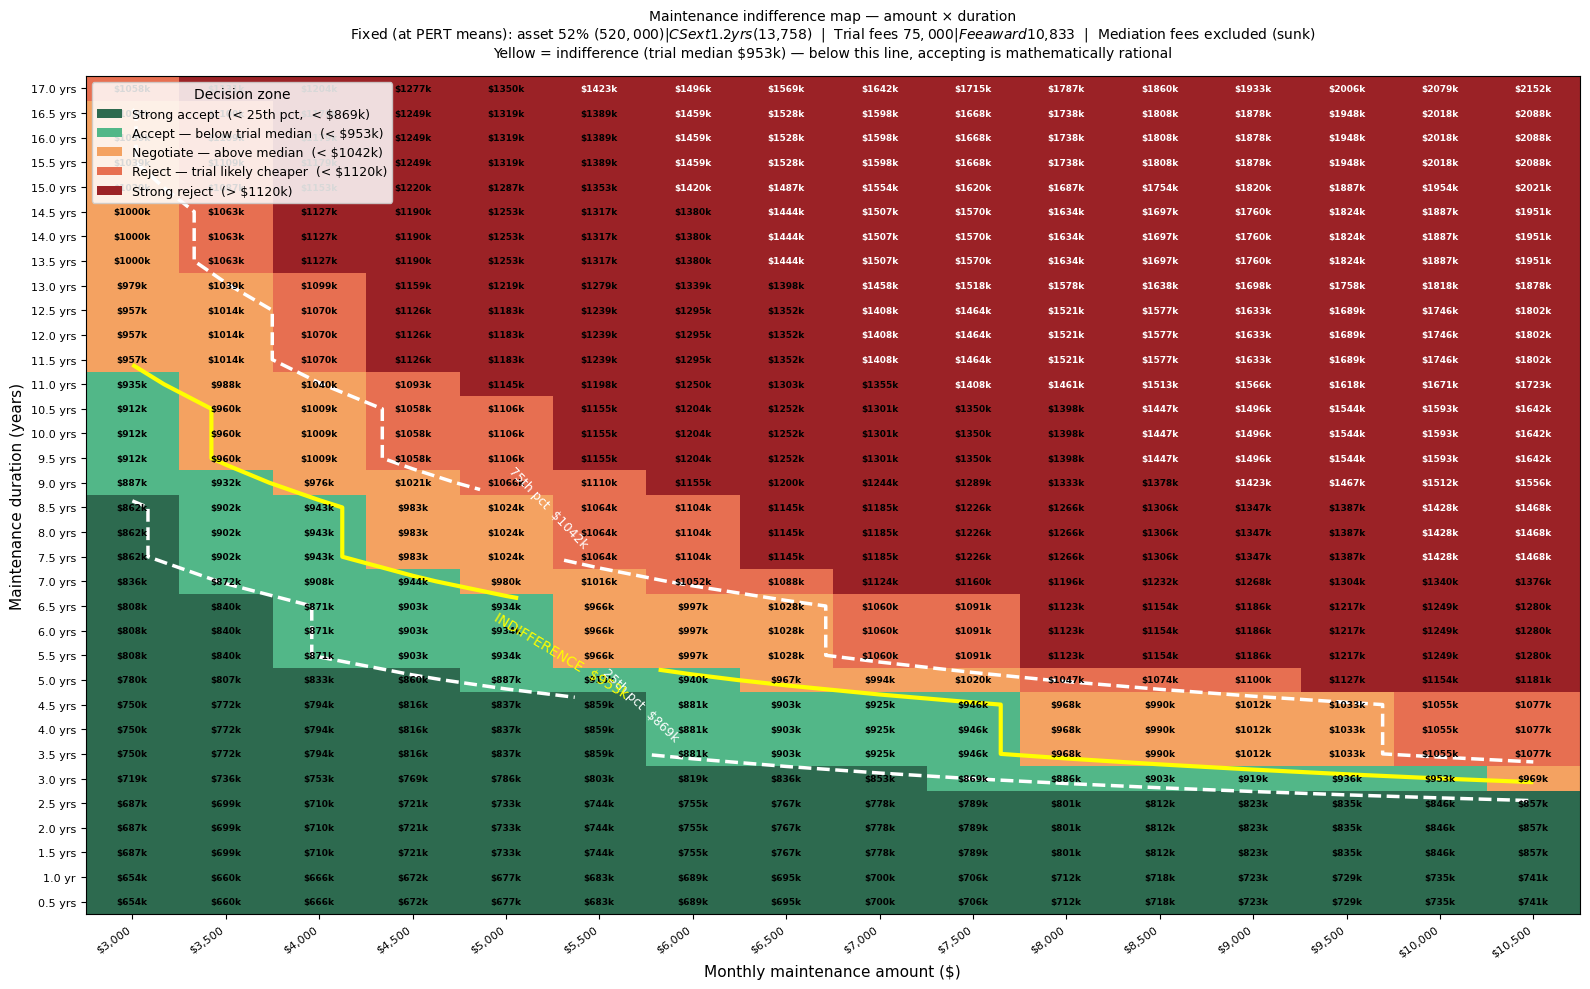


Heatmap fixed cost assumptions (incremental, July 6 forward):
  Asset division (52%):       $   520,000
  CS extension (1.2 yr mean):   $    13,758
  Trial legal fees:              $    75,000
  Expected fee award:            $    10,833
  Mediation fees:                      sunk
  ────────────────────────────────────────────────────────────────
  Total fixed (trial path):      $   619,592


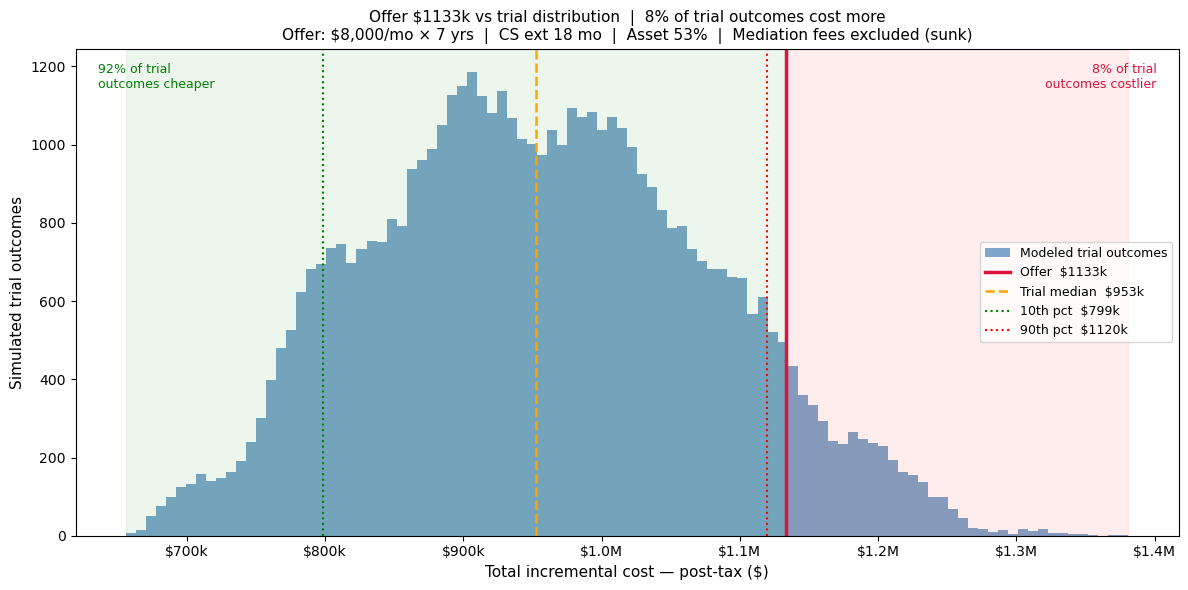

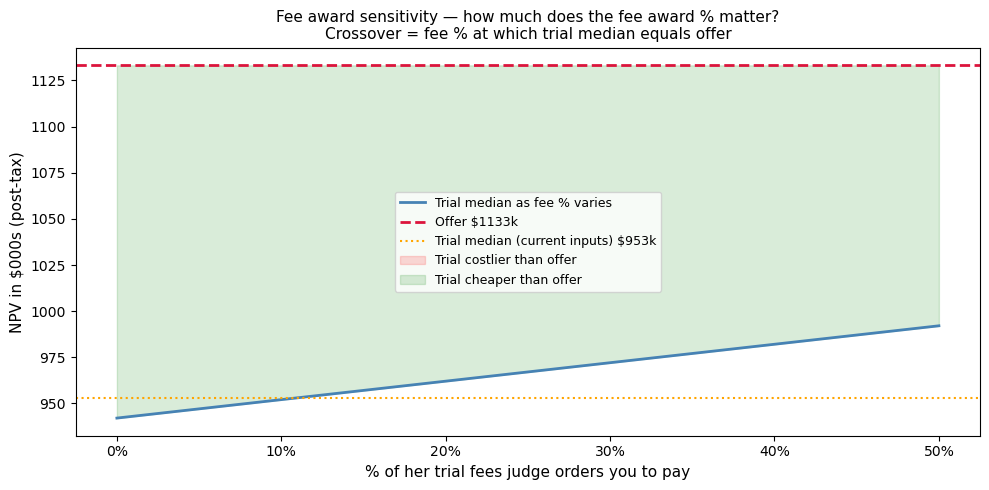


  QUICK CALCULATOR — July 6 real-time use

  [Her opening]
  $10,000/mo × 12 yrs  |  CS 36 mo  |  Asset 55%
  Total: $1,715,916  |  vs median $952,767  |  0% of trial outcomes costlier
  → STRONG REJECT

  [First concession]
  $9,000/mo × 9 yrs  |  CS 24 mo  |  Asset 54%
  Total: $1,370,003  |  vs median $952,767  |  0% of trial outcomes costlier
  → STRONG REJECT

  [Middle ground]
  $8,000/mo × 7 yrs  |  CS 18 mo  |  Asset 53%
  Total: $1,133,185  |  vs median $952,767  |  8% of trial outcomes costlier
  → STRONG REJECT

  [Approaching target]
  $7,000/mo × 5 yrs  |  CS 12 mo  |  Asset 52%
  Total: $907,711  |  vs median $952,767  |  63% of trial outcomes costlier
  → ACCEPT

  [Your walk-in target]
  $6,000/mo × 4 yrs  |  CS 12 mo  |  Asset 50%
  Total: $775,111  |  vs median $952,767  |  94% of trial outcomes costlier
  → STRONG ACCEPT


775110.6869157242

In [16]:
# =============================================================================
# MEDIATION DECISION MODEL
# Spousal maintenance NPV analysis for July 6 mediation
# =============================================================================
# STRUCTURE:
#   Cell 1  — Imports
#   Cell 2  — All inputs (edit these before mediation)
#   Cell 3  — Helper functions
#   Cell 4  — Monte Carlo simulation (trial distribution)
#   Cell 5  — Indifference thresholds
#   Cell 6  — Offer evaluator (run during mediation)
#   Cell 7  — Indifference heatmap
#   Cell 8  — Settlement vs trial histogram
#   Cell 9  — Fee award sensitivity panel
#   Cell 10 — Quick calculator (run in real time on July 6)
# =============================================================================


# -----------------------------------------------------------------------------
# CELL 1 — IMPORTS
# -----------------------------------------------------------------------------

import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import BoundaryNorm


# -----------------------------------------------------------------------------
# CELL 2 — ALL INPUTS
# Edit these before mediation based on Friday attorney conversation.
# Each parameter is annotated with its source and confidence level.
# -----------------------------------------------------------------------------

# --- Discount rate ---
# Reflects conservative investment return on settlement proceeds.
# 4% is appropriate for a balanced portfolio.
discount_rate     = 0.04

# --- Marginal tax rate ---
# Used for pre-tax display only — NOT used in comparison calculations.
# Post-2018: maintenance is neither deductible nor taxable.
# The court sees post-tax dollars; you feel pre-tax. Both shown.
marginal_tax_rate = 0.35

# --- Retirement portfolio ---
# CONFIRM WITH ATTORNEY FRIDAY: exact value at date of separation.
# This is already in present dollars — no discounting needed.
portfolio_value   = 1_000_000

# --- Maintenance PERT inputs (annual amounts) ---
# Source: attorney transcript + Washington case law research.
# Mode = $8,000/month anchored on temporary orders (attorney: "court
# would be hard-pressed to do something other than the eight thousand").
# Confidence: mode HIGH | low/high MODERATE.
# UPDATE if vocational assessment changes imputed income picture.
amount_low   =  48_000    # $4,000/mo — imputed income reduces delta
amount_mode  =  96_000    # $8,000/mo — temporary order anchor
amount_high  = 120_000    # $10,000/mo — judge recalculates independently

# --- Maintenance duration PERT inputs (years) ---
# Source: attorney transcript direct quotes.
# "Worst case is probably six or seven years" — attorney, transcript.
# "Four years" named as middle-ground outcome — attorney, transcript.
# "Six months" named as attorney's trial argument floor.
# Confidence: mode HIGH | low/high MODERATE-HIGH.
years_low    =   0.5      # 6 months — attorney's floor argument
years_mode   =   4.0      # 4 years — attorney's middle-ground reference
years_high   =   7.0      # 7 years — attorney's direct "worst case" quote

# --- Correlation between maintenance amount and duration ---
# Positive: a judge generous on amount tends to extend duration too.
# Relevant for 28-year marriage with non-working spouse.
# Confidence: direction HIGH | magnitude LOW (0.30 is a judgment call).
rho          =   0.30

# --- Child support extension PERT inputs (years beyond 18th birthday) ---
# Twins turn 18 November 2026. Diagnoses: dyscalculia, ADHD, anxiety,
# high-functioning autism. 1-2 years behind in school.
# Source: MY ESTIMATES — replace with attorney's Friday assessment.
# Confidence: LOW. Ask attorney directly for these three numbers.
cs_monthly   =  1_192.38  # current child support order (monthly)
cs_ext_low   =   0.0      # judge declines extension
cs_ext_mode  =   1.0      # most likely: 1 year given diagnoses
cs_ext_high  =   3.0      # maximum: 3 years

# --- Asset division PERT inputs (spouse's share of portfolio) ---
# Washington default is 50/50 community property.
# Source: general Washington law — confirm specific asset picture Friday.
# Confidence: LOW on range. Ask attorney if anything deviates from 50/50.
asset_pct_low    =  0.50   # 50/50 Washington default
asset_pct_mode   =  0.52   # slight deviation toward spouse
asset_pct_high   =  0.57   # aggressive deviation

# --- Legal fees ---
# Trial fees: attorney said $25k retainer is the floor, rarely only that.
# Mediation fees: SUNK — excluded from all incremental comparisons.
# Source: attorney transcript estimates.
# Confidence: MODERATE. Confirm trial fee estimate Friday.
kelly_mediation_fees =  10_000   # SUNK — not used in calculations
kelly_trial_fees     =  75_000   # incremental cost if trial
jen_trial_fees       = 100_000   # her trial fees (basis for fee award)

# --- Her fee award PERT (% of her trial fees judge orders you to pay) ---
# Source: RCW 26.09.140 research + attorney transcript.
# Attorney: "under no circumstances" in settlement; trial is different.
# Research: fee awards disfavored, require showing of need/indigency.
# Post-maintenance, income gap narrows — weakens fee award argument.
# Confidence: LOW. Ask attorney Friday for Snohomish-specific view.
pct_her_fees_low  =  0.00    # judge declines (most likely per attorney)
pct_her_fees_mode =  0.10    # partial award — realistic central tendency
pct_her_fees_high =  0.25    # ceiling given maintenance already ordered

# --- Simulation size ---
n_sims = 50_000


# -----------------------------------------------------------------------------
# CELL 3 — HELPER FUNCTIONS
# -----------------------------------------------------------------------------

def npv_stream(monthly_amount, n_years, rate):
    """
    Post-tax NPV of a monthly payment stream.
    Converts monthly to annual, discounts year by year.
    This is the correct basis for comparing settlement to trial —
    it matches what the court orders and what leaves your account.
    """
    annual  = monthly_amount * 12
    n_years = max(1, int(round(n_years)))
    return sum(annual / (1 + rate)**t for t in range(1, n_years + 1))


def npv_pretax_display(monthly_amount, n_years, rate, tax_rate):
    """
    Pre-tax equivalent — what you must earn to fund each payment.
    Used for economic cost display only, not for settlement comparison.
    At 35% marginal rate, multiply post-tax NPV by 1/(1-0.35) = 1.538.
    """
    return npv_stream(
        monthly_amount / (1 - tax_rate), n_years, rate
    )


def pert_params(lo, mode, hi, lam=4):
    """
    Convert PERT three-point estimate to Beta distribution
    shape parameters alpha and beta.
    lam=4 is standard PERT weighting on the mode.
    """
    mean = (lo + lam * mode + hi) / (lam + 2)
    if abs(mean - mode) < 1e-9:
        alpha = 1 + lam / 2
    else:
        alpha = ((mean - lo) * (2 * mode - lo - hi)) / \
                ((mode - mean) * (hi - lo))
    beta = alpha * (hi - mean) / (mean - lo)
    return alpha, beta


def pert_draw(u, lo, mode, hi, lam=4):
    """
    Map correlated uniform [0,1] values to PERT-distributed samples
    using the Beta quantile function (inverse CDF).
    Preserves correlation structure from the Gaussian copula.
    """
    alpha, beta = pert_params(lo, mode, hi, lam)
    return lo + stats.beta.ppf(
        np.clip(u, 1e-6, 1 - 1e-6), alpha, beta
    ) * (hi - lo)


def fmt_k(x, pos=None):
    """Formatter for axis tick labels: $150k or $1.2M."""
    if x >= 1_000_000:
        return f"${x/1_000_000:.1f}M"
    return f"${x/1_000:.0f}k"


# -----------------------------------------------------------------------------
# CELL 4 — MONTE CARLO SIMULATION
#
# Each of the n_sims trials draws:
#   (1) Maintenance amount and duration — correlated via Gaussian copula
#   (2) Child support extension duration — independent PERT
#   (3) Asset division percentage — independent PERT
#   (4) Her fee award percentage — independent PERT
#
# The copula preserves positive correlation between amount and duration:
#   Step 1 — Draw two correlated standard normals using rho
#   Step 2 — Convert to uniform [0,1] via normal CDF
#   Step 3 — Map uniforms to PERT values via Beta quantile function
# -----------------------------------------------------------------------------

np.random.seed(42)   # reproducibility — remove for fresh draws each run

# Correlated draws for maintenance amount and duration
cov     = [[1, rho], [rho, 1]]
normals = np.random.multivariate_normal([0, 0], cov, size=n_sims)
u_amt   = stats.norm.cdf(normals[:, 0])
u_yrs   = stats.norm.cdf(normals[:, 1])

# Independent draws for remaining variables
u_cs    = np.random.uniform(0, 1, n_sims)
u_asset = np.random.uniform(0, 1, n_sims)
u_fees  = np.random.uniform(0, 1, n_sims)

# Sample each variable from its PERT distribution
sim_amounts   = pert_draw(u_amt,   amount_low,       amount_mode,
                                   amount_high)
sim_years     = pert_draw(u_yrs,   years_low,        years_mode,
                                   years_high)
sim_cs_ext    = pert_draw(u_cs,    cs_ext_low,       cs_ext_mode,
                                   cs_ext_high)
sim_asset_pct = pert_draw(u_asset, asset_pct_low,    asset_pct_mode,
                                   asset_pct_high)
sim_fee_pct   = pert_draw(u_fees,  pct_her_fees_low,
                                   pct_her_fees_mode + 1e-9,
                                   pct_her_fees_high)

# NPV of each component across all simulations
# PV1: maintenance (post-tax, monthly to annual)
pv1_trial = np.array([
    npv_stream(a / 12, y, discount_rate)
    for a, y in zip(sim_amounts, sim_years)
])

# PV2: child support extension
pv2_trial = np.array([
    npv_stream(cs_monthly, ext, discount_rate)
    for ext in sim_cs_ext
])

# PV3: asset division
pv3_trial = sim_asset_pct * portfolio_value

# PV4: your trial legal fees (certain on trial path)
pv4_trial = kelly_trial_fees   # scalar — same for every simulation

# PV5: her fee award (probabilistic)
pv5_trial = sim_fee_pct * jen_trial_fees

# Total incremental trial cost per simulation
# Mediation fees excluded — sunk cost as of July 6
trial_total = (pv1_trial
               + pv2_trial
               + pv3_trial
               + pv4_trial
               + pv5_trial)

# Pre-tax equivalent for display (maintenance component only)
pv1_trial_pretax = np.array([
    npv_pretax_display(a / 12, y, discount_rate, marginal_tax_rate)
    for a, y in zip(sim_amounts, sim_years)
])
trial_total_pretax = (pv1_trial_pretax + pv2_trial
                      + pv3_trial + pv4_trial + pv5_trial)

print("Monte Carlo simulation complete.")
print(f"  Simulations run:       {n_sims:,}")
print(f"  Mean maintenance/mo:   ${sim_amounts.mean()/12:,.0f}")
print(f"  Mean duration (yrs):   {sim_years.mean():.1f}")
print(f"  Mean CS extension:     {sim_cs_ext.mean():.1f} yrs")
print(f"  Mean asset split:      {sim_asset_pct.mean()*100:.1f}%")
print(f"  Mean fee award:        ${(sim_fee_pct * jen_trial_fees).mean():,.0f}")


# -----------------------------------------------------------------------------
# CELL 5 — INDIFFERENCE THRESHOLDS
# -----------------------------------------------------------------------------

p10 = np.percentile(trial_total, 10)
p25 = np.percentile(trial_total, 25)
p50 = np.percentile(trial_total, 50)   # indifference point
p75 = np.percentile(trial_total, 75)
p90 = np.percentile(trial_total, 90)

# Component medians for transparency
pv1_median  = np.median(pv1_trial)
pv2_median  = np.median(pv2_trial)
pv3_median  = np.median(pv3_trial)
avg_fees    = np.mean(pv5_trial)

sep  = "=" * 64
sep2 = "─" * 64

print(sep)
print("  TRIAL DISTRIBUTION — INCREMENTAL COSTS FROM JULY 6")
print("  (Mediation fees excluded — sunk cost)")
print(sep)
print(f"\n  Component medians:")
print(f"    PV1 Maintenance NPV:       ${pv1_median:>10,.0f}")
print(f"    PV2 CS extension NPV:      ${pv2_median:>10,.0f}")
print(f"    PV3 Asset division:        ${pv3_median:>10,.0f}")
print(f"    Trial legal fees (cert):   ${kelly_trial_fees:>10,.0f}")
print(f"    Avg fee award:             ${avg_fees:>10,.0f}")
print(f"\n  Percentile reference points:")
print(f"    10th pct (good day):       ${p10:>10,.0f}")
print(f"    25th pct:                  ${p25:>10,.0f}")
print(f"    Median — INDIFFERENCE:     ${p50:>10,.0f}  ← key number")
print(f"    75th pct:                  ${p75:>10,.0f}")
print(f"    90th pct (bad day):        ${p90:>10,.0f}")
print(f"    Expected value:            "
      f"${np.mean(trial_total):>10,.0f}")


# -----------------------------------------------------------------------------
# CELL 6 — OFFER EVALUATOR
#
# Call evaluate_offer() each time her position changes on July 6.
# Returns total settlement cost and prints a verdict with
# explicit assumption language.
# -----------------------------------------------------------------------------

def evaluate_offer(offer_monthly, offer_years,
                   offer_asset_pct, offer_cs_months=0,
                   label="Offer"):
    """
    Evaluate a settlement offer against the trial distribution.

    offer_monthly   : proposed monthly maintenance ($)
    offer_years     : proposed maintenance duration (years)
    offer_asset_pct : proposed share of portfolio to spouse (0-1)
    offer_cs_months : proposed child support extension (months)
    label           : descriptive label for the printout

    Mediation fees are excluded — sunk cost.
    All figures in post-tax dollars (court-ordered basis).
    """

    # Three present value components
    pv1 = npv_stream(offer_monthly, offer_years, discount_rate)
    pv2 = npv_stream(cs_monthly, offer_cs_months / 12, discount_rate)
    pv3 = offer_asset_pct * portfolio_value

    # Settlement total — no mediation fees (sunk)
    total    = pv1 + pv2 + pv3
    pv1_pt   = npv_pretax_display(offer_monthly, offer_years,
                                   discount_rate, marginal_tax_rate)
    total_pt = pv1_pt + pv2 + pv3

    pct_worse  = np.mean(trial_total > total) * 100
    pct_better = 100 - pct_worse

    # Verdict with explicit assumption language
    if total < p25:
        verdict = "STRONG ACCEPT"
        vcolor  = "darkgreen"
        explain = (
            f"Below the 25th percentile of trial outcomes.\n"
            f"  Assuming a judge draws maintenance from\n"
            f"  ${amount_low/12:,.0f}–${amount_high/12:,.0f}/mo PERT, duration\n"
            f"  {years_low}–{years_high} yrs, CS extension 0–{cs_ext_high:.0f} yrs,\n"
            f"  asset split {asset_pct_low*100:.0f}–{asset_pct_high*100:.0f}%,\n"
            f"  and fee award 0–{pct_her_fees_high*100:.0f}% of her fees:\n"
            f"  75% of trial outcomes cost MORE. Accept."
        )
    elif total < p50:
        verdict = "ACCEPT  (below trial median)"
        vcolor  = "green"
        explain = (
            f"Below the trial median under our assumptions.\n"
            f"  {pct_worse:.0f}% of modeled trial outcomes cost more.\n"
            f"  The math favors acceptance even if uncomfortable.\n"
            f"  Rational to accept."
        )
    elif total < p75:
        verdict = "NEGOTIATE  (above median, within range)"
        vcolor  = "orange"
        explain = (
            f"Above the trial median but below the 75th percentile.\n"
            f"  {pct_worse:.0f}% of modeled trial outcomes cost more.\n"
            f"  Push back on monthly amount or duration before\n"
            f"  accepting. A concession to below the median is\n"
            f"  achievable and worth pursuing."
        )
    elif total < p90:
        verdict = "REJECT  (trial likely cheaper)"
        vcolor  = "red"
        explain = (
            f"Exceeds the 75th percentile of trial outcomes.\n"
            f"  Only {pct_worse:.0f}% of modeled trial outcomes cost more.\n"
            f"  Under our assumptions the math favors trial\n"
            f"  unless you place very high value on certainty."
        )
    else:
        verdict = "STRONG REJECT  (trial almost certainly cheaper)"
        vcolor  = "darkred"
        explain = (
            f"Exceeds the 90th percentile of trial outcomes.\n"
            f"  Only {pct_worse:.0f}% of modeled trial outcomes cost more.\n"
            f"  This offer is not grounded in Washington case law\n"
            f"  as our model applies it. Do not accept."
        )

    print(f"\n{sep}")
    print(f"  {label.upper()}")
    print(f"{sep}")
    print(f"  PV1 Maintenance NPV (post-tax): ${pv1:>10,.0f}")
    print(f"       pre-tax equivalent:         ${pv1_pt:>10,.0f}")
    print(f"       ({offer_monthly:,}/mo × {offer_years} yrs)")
    print(f"  PV2 Child support ext NPV:      ${pv2:>10,.0f}")
    print(f"       ({offer_cs_months} months extension @ "
          f"${cs_monthly:,.2f}/mo)")
    print(f"  PV3 Asset division:             ${pv3:>10,.0f}")
    print(f"       ({offer_asset_pct*100:.1f}% of ${portfolio_value:,})")
    print(f"  Mediation fees:                 "
          f"{'sunk — excluded':>10}")
    print(f"  {sep2}")
    print(f"  TOTAL (post-tax):               ${total:>10,.0f}")
    print(f"  TOTAL (pre-tax equivalent):     ${total_pt:>10,.0f}")
    print(f"\n  Trial reference points:")
    print(f"    Good day    (10th pct):       ${p10:>10,.0f}")
    print(f"    25th pct:                     ${p25:>10,.0f}")
    print(f"    Median (indifference):        ${p50:>10,.0f}")
    print(f"    75th pct:                     ${p75:>10,.0f}")
    print(f"    Bad day     (90th pct):       ${p90:>10,.0f}")
    print(f"\n  Trial outcomes costlier:        {pct_worse:>9.1f}%")
    print(f"  Trial outcomes cheaper:         {pct_better:>9.1f}%")
    print(f"\n  VERDICT: {verdict}")
    print(f"\n  {explain}")

    return total, pct_worse


# --- Run sample evaluations ---
# Replace these with her actual offers as they emerge on July 6

evaluate_offer(
    offer_monthly   = 10_000,
    offer_years     = 12,
    offer_asset_pct = 0.55,
    offer_cs_months = 36,
    label="Her likely opening offer (aggressive)"
)

evaluate_offer(
    offer_monthly   = 8_000,
    offer_years     = 7,
    offer_asset_pct = 0.53,
    offer_cs_months = 18,
    label="Middle-ground scenario"
)

evaluate_offer(
    offer_monthly   = 6_000,
    offer_years     = 4,
    offer_asset_pct = 0.50,
    offer_cs_months = 12,
    label="Near your walk-in target"
)


# -----------------------------------------------------------------------------
# CELL 7 — INDIFFERENCE HEATMAP
#
# Each cell = total TRIAL cost if judge orders exactly that
# monthly amount for exactly that many years.
#
# Fixed across all cells (held at PERT means):
#   - Asset division at mode
#   - Child support extension at PERT mean
#   - Your trial legal fees (certain)
#   - Expected fee award (PERT mean of fee percentage)
#   - Mediation fees excluded (sunk)
#
# Color zones keyed to trial percentile thresholds.
# Yellow line = indifference point (trial median).
# Below yellow = accepting is mathematically rational.
# -----------------------------------------------------------------------------

monthly_range = np.arange(3_000, 11_000,  500)
years_range   = np.arange(  0.5,   17.5,  0.5)

# Fixed costs held constant across all cells
heatmap_asset      = asset_pct_mode * portfolio_value
cs_ext_mean        = (cs_ext_low + 4 * cs_ext_mode + cs_ext_high) / 6
heatmap_cs         = npv_stream(cs_monthly, cs_ext_mean, discount_rate)
heatmap_trial_fees = kelly_trial_fees
expected_fee_pct   = (pct_her_fees_low
                      + 4 * (pct_her_fees_mode + 1e-9)
                      + pct_her_fees_high) / 6
heatmap_fee_award  = expected_fee_pct * jen_trial_fees

heatmap_fixed = (heatmap_asset
                 + heatmap_cs
                 + heatmap_trial_fees
                 + heatmap_fee_award)
# Mediation fees NOT included — sunk cost

# Build matrix: rows = years, columns = monthly amount
Z = np.zeros((len(years_range), len(monthly_range)))
for i, yrs in enumerate(years_range):
    for j, mo in enumerate(monthly_range):
        Z[i, j] = npv_stream(mo, yrs, discount_rate) + heatmap_fixed

# Plot
fig, ax = plt.subplots(figsize=(16, 10))

levels     = [Z.min(), p25, p50, p75, p90, Z.max()]
colors_map = ["#2d6a4f", "#52b788", "#f4a261", "#e76f51", "#9b2226"]
cmap_heat  = plt.matplotlib.colors.ListedColormap(colors_map)
norm       = BoundaryNorm(levels, cmap_heat.N)

ax.imshow(Z, cmap=cmap_heat, norm=norm,
          aspect="auto", origin="lower")

# Cell labels
for i in range(len(years_range)):
    for j in range(len(monthly_range)):
        val        = Z[i, j]
        brightness = (val - Z.min()) / (Z.max() - Z.min())
        txt_color  = "white" if brightness > 0.5 else "black"
        ax.text(j, i, f"${val/1_000:.0f}k",
                ha="center", va="center",
                fontsize=6.5, color=txt_color, fontweight="bold")

# Indifference contour lines
cs25 = ax.contour(Z, levels=[p25], colors=["white"],
                   linewidths=[2.5], linestyles=["--"])
cs50 = ax.contour(Z, levels=[p50], colors=["yellow"],
                   linewidths=[3.0], linestyles=["-"])
cs75 = ax.contour(Z, levels=[p75], colors=["white"],
                   linewidths=[2.5], linestyles=["--"])
ax.clabel(cs25, fmt=f"25th pct  ${p25/1000:.0f}k",
          fontsize=9,  colors="white")
ax.clabel(cs50, fmt=f"INDIFFERENCE  ${p50/1000:.0f}k",
          fontsize=10, colors="yellow")
ax.clabel(cs75, fmt=f"75th pct  ${p75/1000:.0f}k",
          fontsize=9,  colors="white")

# Axes
ax.set_yticks(range(len(years_range)))
ax.set_yticklabels(
    [f"{y:.1f} yr{'s' if y != 1 else ''}" for y in years_range],
    fontsize=8
)
ax.set_xticks(range(len(monthly_range)))
ax.set_xticklabels(
    [f"${int(m):,}" for m in monthly_range],
    fontsize=8, rotation=35, ha="right"
)
ax.set_ylabel("Maintenance duration (years)", fontsize=11)
ax.set_xlabel("Monthly maintenance amount ($)",  fontsize=11)

# Legend
legend_labels = [
    f"Strong accept  (< 25th pct,  < ${p25/1000:.0f}k)",
    f"Accept — below trial median  (< ${p50/1000:.0f}k)",
    f"Negotiate — above median  (< ${p75/1000:.0f}k)",
    f"Reject — trial likely cheaper  (< ${p90/1000:.0f}k)",
    f"Strong reject  (> ${p90/1000:.0f}k)"
]
patches = [plt.Rectangle((0, 0), 1, 1, fc=c) for c in colors_map]
ax.legend(patches, legend_labels, loc="upper left",
          fontsize=9, framealpha=0.85, title="Decision zone")

ax.set_title(
    "Maintenance indifference map — amount × duration\n"
    f"Fixed (at PERT means): asset {asset_pct_mode*100:.0f}% "
    f"(${heatmap_asset:,.0f})  |  "
    f"CS ext {cs_ext_mean:.1f} yrs (${heatmap_cs:,.0f})  |  "
    f"Trial fees ${heatmap_trial_fees:,.0f}  |  "
    f"Fee award ${heatmap_fee_award:,.0f}  |  "
    f"Mediation fees excluded (sunk)\n"
    f"Yellow = indifference (trial median ${p50/1000:.0f}k) — "
    f"below this line, accepting is mathematically rational",
    fontsize=10, pad=14
)
plt.tight_layout()
plt.savefig("indifference_map.png", dpi=150, bbox_inches="tight")
plt.show()

# Print fixed assumption summary
print(f"\nHeatmap fixed cost assumptions (incremental, July 6 forward):")
print(f"  Asset division ({asset_pct_mode*100:.0f}%):       ${heatmap_asset:>10,.0f}")
print(f"  CS extension ({cs_ext_mean:.1f} yr mean):   ${heatmap_cs:>10,.0f}")
print(f"  Trial legal fees:              ${heatmap_trial_fees:>10,.0f}")
print(f"  Expected fee award:            ${heatmap_fee_award:>10,.0f}")
print(f"  Mediation fees:                {'sunk':>10}")
print(f"  {sep2}")
print(f"  Total fixed (trial path):      ${heatmap_fixed:>10,.0f}")


# -----------------------------------------------------------------------------
# CELL 8 — SETTLEMENT vs TRIAL HISTOGRAM
#
# Plug in a specific offer to see where it sits
# against the full trial distribution.
# -----------------------------------------------------------------------------

# --- SET OFFER HERE ---
offer_monthly_hist   =  8_000
offer_years_hist     =      7
offer_asset_pct_hist =   0.53
offer_cs_months_hist =     18

offer_total_hist = (
    npv_stream(offer_monthly_hist, offer_years_hist, discount_rate)
    + npv_stream(cs_monthly, offer_cs_months_hist / 12, discount_rate)
    + offer_asset_pct_hist * portfolio_value
    # mediation fees excluded — sunk
)
pct_worse_hist = np.mean(trial_total > offer_total_hist) * 100

fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(trial_total, bins=100, color="steelblue",
        alpha=0.7, edgecolor="none",
        label="Modeled trial outcomes")

ax.axvline(offer_total_hist, color="crimson", linewidth=2.5,
           linestyle="-",
           label=f"Offer  ${offer_total_hist/1000:.0f}k")
ax.axvline(p50, color="orange", linewidth=1.8, linestyle="--",
           label=f"Trial median  ${p50/1000:.0f}k")
ax.axvline(p10, color="green",  linewidth=1.5, linestyle=":",
           label=f"10th pct  ${p10/1000:.0f}k")
ax.axvline(p90, color="red",    linewidth=1.5, linestyle=":",
           label=f"90th pct  ${p90/1000:.0f}k")

ax.axvspan(trial_total.min(), offer_total_hist,
           alpha=0.07, color="green")
ax.axvspan(offer_total_hist, trial_total.max(),
           alpha=0.07, color="red")

ax.text(0.02, 0.97,
        f"{100-pct_worse_hist:.0f}% of trial\noutcomes cheaper",
        transform=ax.transAxes, fontsize=9,
        va="top", color="green")
ax.text(0.98, 0.97,
        f"{pct_worse_hist:.0f}% of trial\noutcomes costlier",
        transform=ax.transAxes, fontsize=9,
        va="top", ha="right", color="crimson")

ax.set_xlabel("Total incremental cost — post-tax ($)", fontsize=11)
ax.set_ylabel("Simulated trial outcomes", fontsize=11)
ax.set_title(
    f"Offer ${offer_total_hist/1000:.0f}k vs trial distribution  |  "
    f"{pct_worse_hist:.0f}% of trial outcomes cost more\n"
    f"Offer: ${offer_monthly_hist:,}/mo × {offer_years_hist} yrs  |  "
    f"CS ext {offer_cs_months_hist} mo  |  "
    f"Asset {offer_asset_pct_hist*100:.0f}%  |  "
    f"Mediation fees excluded (sunk)",
    fontsize=11
)
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(fmt_k))
plt.tight_layout()
plt.savefig("settlement_vs_trial.png", dpi=150, bbox_inches="tight")
plt.show()


# -----------------------------------------------------------------------------
# CELL 9 — FEE AWARD SENSITIVITY PANEL
#
# Shows how the trial median moves as the fee award percentage
# varies from 0% to 50%, with the offer as a flat reference line.
# The crossover point = fee % at which trial stops being cheaper.
# -----------------------------------------------------------------------------

fee_pcts = np.linspace(0, 0.50, 200)
trial_medians_by_fee = [
    np.median(
        pv1_trial + pv2_trial + pv3_trial
        + kelly_trial_fees
        + fp * jen_trial_fees
    )
    for fp in fee_pcts
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(fee_pcts * 100,
        [t / 1000 for t in trial_medians_by_fee],
        color="steelblue", linewidth=2,
        label="Trial median as fee % varies")
ax.axhline(offer_total_hist / 1000, color="crimson",
           linewidth=2, linestyle="--",
           label=f"Offer ${offer_total_hist/1000:.0f}k")
ax.axhline(p50 / 1000, color="orange",
           linewidth=1.5, linestyle=":",
           label=f"Trial median (current inputs) ${p50/1000:.0f}k")

ax.fill_between(
    fee_pcts * 100,
    [t / 1000 for t in trial_medians_by_fee],
    offer_total_hist / 1000,
    where=[t > offer_total_hist for t in trial_medians_by_fee],
    alpha=0.15, color="red",
    label="Trial costlier than offer"
)
ax.fill_between(
    fee_pcts * 100,
    [t / 1000 for t in trial_medians_by_fee],
    offer_total_hist / 1000,
    where=[t <= offer_total_hist for t in trial_medians_by_fee],
    alpha=0.15, color="green",
    label="Trial cheaper than offer"
)

ax.set_xlabel("% of her trial fees judge orders you to pay", fontsize=11)
ax.set_ylabel("NPV in $000s (post-tax)", fontsize=11)
ax.set_title(
    "Fee award sensitivity — how much does the fee award % matter?\n"
    "Crossover = fee % at which trial median equals offer",
    fontsize=11
)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.0f}%")
)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fee_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()


# -----------------------------------------------------------------------------
# CELL 10 — QUICK CALCULATOR
#
# Run this in real time on July 6 each time her offer changes.
# Prints a fast verdict — no charts, just the number and signal.
# -----------------------------------------------------------------------------

def quick_compare(offer_monthly, offer_years,
                  offer_asset_pct, offer_cs_months=0,
                  label=""):
    """
    Instant settlement vs trial comparison.
    Call this every time her position changes during mediation.
    Mediation fees excluded — sunk cost.
    """
    pv1   = npv_stream(offer_monthly, offer_years, discount_rate)
    pv2   = npv_stream(cs_monthly, offer_cs_months / 12, discount_rate)
    pv3   = offer_asset_pct * portfolio_value
    total = pv1 + pv2 + pv3

    pct_w = np.mean(trial_total > total) * 100

    if   total < p25: signal = "STRONG ACCEPT"
    elif total < p50: signal = "ACCEPT"
    elif total < p75: signal = "NEGOTIATE"
    elif total < p90: signal = "REJECT"
    else:             signal = "STRONG REJECT"

    tag = f"  [{label}]" if label else ""
    print(f"\n{tag}")
    print(f"  ${offer_monthly:,}/mo × {offer_years} yrs  |  "
          f"CS {offer_cs_months} mo  |  "
          f"Asset {offer_asset_pct*100:.0f}%")
    print(f"  Total: ${total:,.0f}  |  "
          f"vs median ${p50:,.0f}  |  "
          f"{pct_w:.0f}% of trial outcomes costlier")
    print(f"  → {signal}")
    return total


# --- Sample sequence — replace with actual offers on July 6 ---
print("\n" + sep)
print("  QUICK CALCULATOR — July 6 real-time use")
print(sep)

quick_compare(10_000, 12, 0.55, 36, "Her opening")
quick_compare( 9_000,  9, 0.54, 24, "First concession")
quick_compare( 8_000,  7, 0.53, 18, "Middle ground")
quick_compare( 7_000,  5, 0.52, 12, "Approaching target")
quick_compare( 6_000,  4, 0.50, 12, "Your walk-in target")